# Topic Modeling con BERTopic, LDA y NMF

> **Práctica de NLP** — Extracción automática de tópicos de colecciones de texto

---

## Tabla de contenidos

0. [Setup e Instalación](#0)
1. [Carga y Exploración del Dataset](#1)
2. [Preprocesamiento de Texto](#2)
3. [LDA — Latent Dirichlet Allocation](#3)
4. [NMF — Non-negative Matrix Factorization](#4)
5. [BERTopic — Embeddings Neurales](#5)
6. [Etiquetas automáticas con LLMs gratuitos](#6)
7. [Comparativa de Métodos](#7)
8. [Visualización Interactiva](#8)

---

**Entornos compatibles:** Jupyter Lab · Jupyter Notebook · VS Code · Google Colab  
**Requisitos de API:** Ninguno (todo gratuito)

---
## 0. Setup e Instalación <a id='0'></a>

In [1]:
# Instalar dependencias (descomentar si es necesario)
!pip install bertopic sentence-transformers umap-learn hdbscan
!pip install scikit-learn gensim nltk datasets
!pip install pyldavis plotly huggingface_hub

# Para modelos locales (Opción A de etiquetado):
!pip install transformers accelerate

# En Google Colab, ejecuta primero:
!pip install bertopic sentence-transformers umap-learn hdbscan gensim pyldavis huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 52.8 MB/s eta 0:00:00


In [2]:
!pip install seaborn -q
!pip install matplotlib -q
!pip install pandas -q
!pip install numpy -q
!pip install scikit-learn -q
!pip install nltk -q

In [3]:
!pip install emoji -q
!pip install langdetect -q
!pip install keybert -q
!pip install sentence-transformers -q
!pip install sentence-transformers umap-learn -q
!pip install pandarallel -q
!pip install flair -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 36.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 142.3 MB/s eta 0:00:0

In [4]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install plotly
!pip install scikit-learn
!pip install bertopic
!pip install gensim

In [5]:
import warnings
warnings.filterwarnings('ignore')
import re
# Core
import numpy as np
import pandas as pd
from pathlib import Path
import emoji


# Visualización
import matplotlib.pyplot as plt
import plotly.express as px

# NLP clásico
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# BERTopic y dependencias
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Representación sin LLM (gratuitas, siempre disponibles)
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

# Métricas
import gensim.corpora as corpora
from gensim.models import CoherenceModel

print('✓ Todas las librerías importadas correctamente')

✓ Todas las librerías importadas correctamente


In [6]:
from langdetect import detect, DetectorFactory
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

---
## Tarea 2.1. Carga y Exploración del Dataset <a id='1'></a>

Usaremos un dataset de series de televisión. Después de cargarlo, vamos a analizarlo.

In [9]:
df = pd.read_csv('data.csv')
df.head(5)
docs = df['overview'].dropna().tolist()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168639 entries, 0 to 168638
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  168639 non-null  int64 
 1   name                168634 non-null  object
 2   overview            93333 non-null   object
 3   number_of_seasons   168639 non-null  int64 
 4   number_of_episodes  168639 non-null  int64 
 5   genres              99713 non-null   object
 6   created_by          36496 non-null   object
dtypes: int64(3), object(4)
memory usage: 9.0+ MB


Vamos a empezar con la exploración inicial del dataset. Veamos las características más básicas del dataset, como el número de filas, de columnas...


In [10]:
df.shape

(168639, 7)

In [11]:
df.columns


Index(['id', 'name', 'overview', 'number_of_seasons', 'number_of_episodes',
       'genres', 'created_by'],
      dtype='object')

In [12]:
df.dtypes

,0
id,int64
name,object
overview,object
number_of_seasons,int64
number_of_episodes,int64
genres,object
created_by,object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168639 entries, 0 to 168638
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  168639 non-null  int64 
 1   name                168634 non-null  object
 2   overview            93333 non-null   object
 3   number_of_seasons   168639 non-null  int64 
 4   number_of_episodes  168639 non-null  int64 
 5   genres              99713 non-null   object
 6   created_by          36496 non-null   object
dtypes: int64(3), object(4)
memory usage: 9.0+ MB


Como podemos ver, el dataset tiene 168639 registros y 7 columnas. Esas siete columnas son:
- ID: El localizador el registro
- Name: El nombre de la serie
- Overview: La trama de la serie
- Number_of_seasons: El número de temporadas
- Number_of_episodes: El número total de episodios de la serie
- Genres: Los generos de la serie
- Created_by: creador de la serie

Las columnas más importantes son las de `overview` y las de `genres`. También podría considerarse importante la columna de `created_by`, ya que muchas veces nos guiamos por el director de la serie para decidir si la vemos o no. No es lo mismo saber que el creador de la serie es el mismo que el creado de Juego de Tronos, que que el creador sea el de My Little Pony.

Tampoco hay que ignorar las columnas de `number_of_seasons` y `number_of_episodes`, ya que si vemos que la serie tiene 30 temporadas, puede darnos pereza verla. También el número de episodios importa ya que si tiene pocos puede ser una miniserie y poder recomendarse para verse en un fin de semana.

En conclusión, aunque parezcan pocas columnas, tenemos un dataset rico en información que podrá utilizarse para recomendar series a los clientes.

También se observa que hay muchas columnas con valores nulos o vacias. El mayor problema es que esas celdas vacias se encuentran en la columna `overview`. Sin el resumen, dificilmente podremos saber sobre qué trata la serie. También hay celdas vacias en las columnas de `genres` y `created_by`, otras dos columnas importantes. Más adelante veremos qué hacer con esas celdas.


In [86]:
longitudes_palabras = df["overview"].astype(str).str.split().str.len()

longitudes_palabras.describe()

,overview
count,63076.000000
mean,57.019231
std,43.770980
min,1.000000
25%,26.000000
50%,44.000000
75%,75.000000
max,1839.000000


Como vemos, la entrada más larga tiene casi 1839 palabras, una descripción realmente larga.

En cambio, la mas corta, tiene 1, breve.

La longitud media es de 57 palabras por descripción.

## Tarea 2.2 Preprocesamiento.

El preprocesamiento lo iremos haciendo a la vez que un pequeño EDA, para así tomar las decisiones basadas en fundamentos críticos. En este apartado, contestaremos a las otras dos preguntas que faltan del EDA que se piden en el enunciado.

In [14]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df.head()

,id,name,overview,number_of_seasons,number_of_episodes,genres,created_by
0,1399,Game of Thrones,"Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.",8,73,"Sci-Fi & Fantasy, Drama, Action & Adventure","David Benioff, D.B. Weiss"
1,71446,Money Heist,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.",3,41,"Crime, Drama",Álex Pina
2,66732,Stranger Things,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.",4,34,"Drama, Sci-Fi & Fantasy, Mystery","Matt Duffer, Ross Duffer"
3,1402,The Walking Dead,Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,11,177,"Action & Adventure, Drama, Sci-Fi & Fantasy",Frank Darabont
4,63174,Lucifer,"Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.",6,93,"Crime, Sci-Fi & Fantasy",Tom Kapinos


Como vemos, son series conocidas (no todas serán conocidas porque 168000 series son muchas series). La descripción de la serie es breve y concisa, sin entrar en muchos detalles. También se observa que las series pueden tener más de un género y que a priori las descripciones están en inglés. El idioma en el que esté la información es importante, porque si hay más de un idioma presente en las descripciones, el sistema de recomendación podría fallar.

In [15]:
df.nunique()

,0
id,164705
name,155586
overview,91243
number_of_seasons,82
number_of_episodes,967
genres,2228
created_by,26081


In [16]:
df.isnull().sum()

,0
id,0
name,5
overview,75306
number_of_seasons,0
number_of_episodes,0
genres,68926
created_by,132143


In [17]:
df.duplicated().sum()

np.int64(3631)

Como vemos, hay 1920 filas con valores duplicados. Es decir, hay entradas repetidas. Vamos a eliminarlas. También vemos que hay 75306 filas a las que les falta el resumen, 68927 filas a las que les falta el genero y 132144 filas a las que les falta el creador. También hay 5 filas que no tienen nombre.

Vamos a empezar por eliminar las filas duplicadas y a las que les falten las dos columnas más importantes: `genres` y `overview`

In [18]:
df = df.drop_duplicates()

In [19]:
df = df[~((df['overview'].fillna('') == '') & (df['genres'].fillna('') == ''))]

In [20]:
df.isnull().sum()

,0
id,0
name,0
overview,34342
number_of_seasons,0
number_of_episodes,0
genres,28491
created_by,92390


In [21]:
df.nunique()

,0
id,125925
name,119087
overview,91243
number_of_seasons,82
number_of_episodes,951
genres,2228
created_by,24698


Tras eliminar las filas con valores nulos en común, vemos que todavía tenemos 34342 resumenes faltantes, 28491 generos faltantes y 92390 creadores faltantes. Teniendo en cuenta que de 125925 entradas que nos quedan, 92390 no tienen director (el 73.37%), creemos conveniente eliminar esa columna, debido a su alto número de valores faltantes.

In [22]:
df = df.drop(columns=['created_by'])

También vemos necesario eliminar las filas que no tienen resumen o genero.

In [23]:
df = df[df['overview'].notna() & (df['overview'] != '')]
df = df[df['genres'].notna() & (df['genres'] != '')]

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63310 entries, 0 to 168636
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  63310 non-null  int64 
 1   name                63310 non-null  object
 2   overview            63310 non-null  object
 3   number_of_seasons   63310 non-null  int64 
 4   number_of_episodes  63310 non-null  int64 
 5   genres              63310 non-null  object
dtypes: int64(3), object(3)
memory usage: 3.4+ MB


Finalmente, el dataset queda con estas entradas.

,count
genres,
Drama,23615
Comedy,16509
Documentary,12210
Animation,9152
Reality,6460
Action & Adventure,5781
Sci-Fi & Fantasy,5533
Crime,4774
Mystery,3800


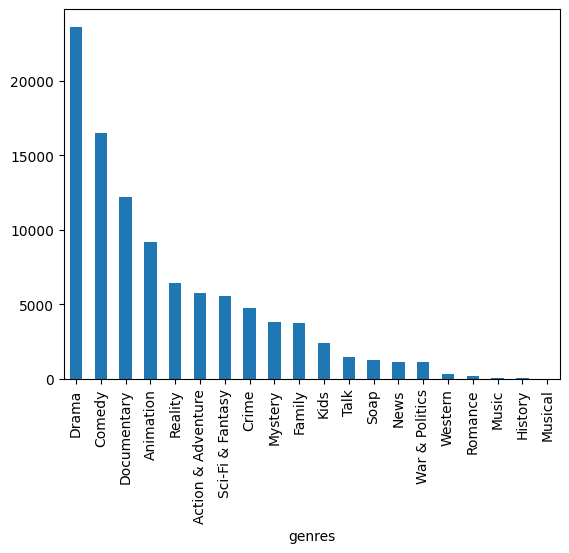

In [25]:
display(df["genres"].str.split(', ').explode().value_counts())
genres_counts = df["genres"].str.split(', ').explode().value_counts()
genres_counts.plot(kind='bar')
plt.show()

Como vemos, hay 20 generos (19 si consideramos Musical y Music lo mismo), y la distribución que siguen es la que se ve en la imagen. El genero que predomina es el de Drama, seguido de Comedy y Documentary. Por la cola tenemos una entrada de Musical, 28 de Historia y 62 de Music. No obstante, como ya se ha comentado, hay que tener en cuenta que a un tercio de las entradas les falta el genero. Vamos a intentar solucionar eso haciendo un pequeño modelo que, dada una descripción, intente deducir el genero. Para ello, utilizaremos los 63310 registros que tenemos con genero y descripción para entrenar, evaluar y testear el modelo. Si los resultados nos convencen, utilizaremos el modelo para predecir los generos.


Antes de proceder con el entrenamiento, vamos a ver si todas las entradas están en inglés. Todos los resúmenes que no estén en inglés serán eliminados, para trabajar solo con un idioma. Vamos a utilizar `langdetect` para detectar el idioma. No obstante, como `langdetect` puede fallar, vamos también a aplicar reglas hardcodeadas.
- Vamos a generar mediante el uso de IA un diccionario de palabras comunes en inglés en este contexto.
- Si un 15% de las palabras que componen la descripción están dentro de ese diccionario, consideraremos que el texto está en inglés.
- Esto se ahce así porque, puede suceder que `langdetect` detecte una descripción en otro idioma porque la frase sea algo del estilo: "El último superviviente is a documentary". Puede ser que como vea las primeras 3 palabras en español, se piense que la descripción esté en español. Por eso mismo, introducimos las reglas Hardcodeadas.

In [26]:
DetectorFactory.seed = 42

# --- Constantes (compiladas una vez) ---
_RE_TOKENS = re.compile(r"\w+")
_RE_DIGITS = re.compile(r"\d+$")
_RE_TITLE_SEP = re.compile(
    r"^(?P<title>.+?)(?P<sep>\s+(?:is|was|are|were|seems|looks|appears|becomes)\s+"
    r"|\s*[:\-–—]\s+"
    r"|\s*\(\s*)",
    flags=re.I
)

ENGLISH_STOPWORDS = frozenset(stopwords.words('english'))
ENGLISH_SIGNAL_WORDS = frozenset({
    'is', 'was', 'are', 'were', 'a', 'an', 'the', 'series', 'television',
    'starring', 'produced', 'created', 'directed', 'premiered', 'episode',
    'episodes', 'season', 'seasons', 'network', 'aired', 'broadcast',
    'runtime', 'documentary', 'comedy', 'drama', 'thriller', 'animated',
    'reality', 'historical', 'based', 'set', 'family', 'children', 'story',
    'crime', 'mystery', 'fantasy', 'adventure', 'science'
})
ENGLISH_VOCAB = ENGLISH_STOPWORDS | ENGLISH_SIGNAL_WORDS

COPULA_VERBS = re.compile(
    r"\s+(?:is|was|are|were|seems|looks|appears|becomes)\s+", re.I
)


def _detectar_idioma(texto: str) -> str:
    try:
        return detect(texto)
    except:
        return "unknown"


def _is_mostly_english(tokens: list[str], threshold: float = 0.15) -> bool:
    if not tokens:
        return False
    english_like = sum(
        1 for t in tokens
        if t in ENGLISH_VOCAB or _RE_DIGITS.fullmatch(t)
    )
    return english_like / len(tokens) >= threshold


def _remove_leading_title(texto: str) -> str:
    match = _RE_TITLE_SEP.match(texto)
    if not match:
        return texto

    title = match.group('title').strip()
    title_tokens = _RE_TOKENS.findall(title.lower())
    if not title_tokens or len(title_tokens) > 8:
        return texto

    foreign = sum(
        1 for t in title_tokens
        if t not in ENGLISH_VOCAB and not _RE_DIGITS.fullmatch(t)
    )
    if foreign >= len(title_tokens) / 2:
        return texto[match.end('title'):].strip()

    return texto


def _is_english(texto: str) -> bool:
    tokens = _RE_TOKENS.findall(str(texto).lower())
    if _is_mostly_english(tokens):
        return True
    return _detectar_idioma(texto) == 'en'


def _clean_overview(texto: str) -> str:
    texto = _remove_leading_title(str(texto).strip())
    sentences = re.split(r'(?<=[.!?])\s+', texto)
    kept = [s.strip() for s in sentences if s.strip() and _is_english(s)]
    return ' '.join(kept) or texto


# --- Aplicación al DataFrame ---
if 'overview' not in df.columns:
    raise ValueError("La columna 'overview' no existe en el DataFrame.")

try:
    from pandarallel import pandarallel
    pandarallel.initialize(progress_bar=True, verbose=0)
    df['overview_clean'] = df['overview'].parallel_apply(_clean_overview)
except ImportError:
    df['overview_clean'] = df['overview'].apply(_clean_overview)

df['overview_is_english'] = df['overview_clean'].apply(_is_english)

# --- Estadísticas ---
english_count = df['overview_is_english'].sum()
total = len(df)

print(f"Total overviews analizadas : {total}")
print(f"Overviews en inglés        : {english_count} ({english_count / total:.2%})")
print(f"Overviews no inglés        : {total - english_count} ({(total - english_count) / total:.2%})")

if not df['overview_is_english'].all():
    display(df.loc[~df['overview_is_english'], ['overview', 'overview_clean', 'overview_is_english']].head(40))

Total overviews analizadas : 63310
Overviews en inglés        : 63139 (99.73%)
Overviews no inglés        : 171 (0.27%)


,overview,overview_clean,overview_is_english
3687,La Casa de los Famosos Mexico,La Casa de los Famosos Mexico,False
13405,"Na nova série de comédia Tô de Graça, Rodrigo Sant'Anna interpreta Graça, uma catadora de latas e pedinte, que sustenta seus muitos filhos e o marido desempregado. Assista agora!","Na nova série de comédia Tô de Graça, Rodrigo Sant'Anna interpreta Graça, uma catadora de latas e pedinte, que sustenta seus muitos filhos e o marido desempregado. Assista agora!",False
14934,,,False
19617,French miniseries.,French miniseries.,False
19835,"Nesta série de documentários, reviva as investigações dos crimes mais chocantes do Brasil: os casos Nardoni, Richthofen, Maníaco do Parque e outros.","Nesta série de documentários, reviva as investigações dos crimes mais chocantes do Brasil: os casos Nardoni, Richthofen, Maníaco do Parque e outros.",False
22436,Water Margin (Kids Version),(Kids Version),False
22949,"No talkshow Lady Night, Tatá Werneck recebe celebridades para um bate-papo com muitas brincadeiras e bom humor. Entre os convidados estão Bruna Marquezine, Anitta, Sandy, Tiago Iorc e muito mais!","No talkshow Lady Night, Tatá Werneck recebe celebridades para um bate-papo com muitas brincadeiras e bom humor. Entre os convidados estão Bruna Marquezine, Anitta, Sandy, Tiago Iorc e muito mais!",False
24587,French miniseries.,French miniseries.,False
28241,"Карпов — культовый популярный российский телевизионный сериал от компании Dixi Media, спин-офф телесериалов «Глухарь» и «Пятницкий», рассказывающий о жизни персонажа сериала «Глухарь» - бывшего подполковника милиции Карповa.","— культовый популярный российский телевизионный сериал от компании Dixi Media, спин-офф телесериалов «Глухарь» и «Пятницкий», рассказывающий о жизни персонажа сериала «Глухарь» - бывшего подполковника милиции Карповa.",False
29437,《인어 아가씨》는 MBC에서 2002년 6월 24일부터 2003년 6월 27일까지 246부작으로 방영되었던 드라마이다.,《인어 아가씨》는 MBC에서 2002년 6월 24일부터 2003년 6월 27일까지 246부작으로 방영되었던 드라마이다.,False


In [27]:
df = df[df['overview_is_english']].copy()

Con las filas en otros idiomas eliminadas, vamos a seguir con el EDA y el preprocesamiento. Veamos como ha quedado el dataset después de la eliminación de filas que hemos llevado a cabo.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63139 entries, 0 to 168636
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   63139 non-null  int64 
 1   name                 63139 non-null  object
 2   overview             63139 non-null  object
 3   number_of_seasons    63139 non-null  int64 
 4   number_of_episodes   63139 non-null  int64 
 5   genres               63139 non-null  object
 6   overview_clean       63139 non-null  object
 7   overview_is_english  63139 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 3.9+ MB


A continuación, veamos si tenemos presencia y en qué cantidad de:
- Emoticonos
- Mayúsculas
- Links
- Menciones (@)
- Signos de puntuación

In [29]:
# emojis por review
df['emoji_count'] = df['overview'].apply(lambda x: emoji.emoji_count(str(x)))

# mayúsculas por review
df['caps_ratio'] = df['overview'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)

# url por review
df['has_url'] = df['overview'].apply(lambda x: int(bool(re.search(r'http[s]?://\S+', str(x)))))

# mentions por review
df['has_mention'] = df['overview'].apply(lambda x: int(bool(re.search(r'@\S+', str(x)))))

# puntuaciones por review
df['punct_density'] = df['overview'].apply(lambda x: len(re.findall(r'[!?.¡¿,;:]', str(x))) / len(str(x)) if len(str(x)) > 0 else 0)

display(df.head())


,id,name,overview,number_of_seasons,number_of_episodes,genres,overview_clean,overview_is_english,emoji_count,caps_ratio,has_url,has_mention,punct_density
0,1399,Game of Thrones,"Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.",8,73,"Sci-Fi & Fantasy, Drama, Action & Adventure","Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.",True,0,0.021277,0,0,0.021277
1,71446,Money Heist,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.",3,41,"Crime, Drama","To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.",True,0,0.017964,0,0,0.015968
2,66732,Stranger Things,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.",4,34,"Drama, Sci-Fi & Fantasy, Mystery","When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.",True,0,0.006711,0,0,0.026846
3,1402,The Walking Dead,Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,11,177,"Action & Adventure, Drama, Sci-Fi & Fantasy",Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,True,0,0.020202,0,0,0.010101
4,63174,Lucifer,"Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.",6,93,"Crime, Sci-Fi & Fantasy","Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.",True,0,0.047138,0,0,0.016835


In [30]:
global_stats = df[['emoji_count', 'caps_ratio', 'has_url', 'has_mention', 'punct_density']].mean()
print("Promedio global de estilo del corpus:\n", global_stats)

Promedio global de estilo del corpus:
 emoji_count      0.000824
caps_ratio       0.034680
has_url          0.000143
has_mention      0.000348
punct_density    0.018288
dtype: float64


Si nos fijamos en las métricas, vemos que en el dataset, un 0.08% de los resumenes tienen emoticonos, un 3% de las letras son mayúsucla, un 0.01% tienen una URL, una 0.03% tienen un "@" y un 1.8% de los carácteres son signos de puntuación. Vamos a eliminar las entradas que tengan emoticonos, URL y "@", ya que representan un % mínimo del dataset.

In [31]:
initial_len = len(df)

df = df[~((df['emoji_count'] > 0) | (df['has_url'] == 1) | (df['has_mention'] == 1))]

print(f"Eliminadas {initial_len - len(df)} filas con emoticonos, URLs o @.")

Eliminadas 61 filas con emoticonos, URLs o @.


En total, se han eliminado 61 filas con emoticonos, URLs o @.

Una característica importante de los corpus es el número de palabras únicas.

In [32]:
all_words = [word for text in df['overview'] for word in str(text).split()]

unique_words = set(all_words)

print("Número de palabras únicas en el corpus:", len(unique_words))


Número de palabras únicas en el corpus: 229561


Como vemos, hay 229561 palabras únicas en el corpus. No obstante, hay que coger esto con pinzas, porque no sabemos cuantos nombre ficticios hay en el dataset. Por ejemplo, si en Juego de Tronos (sabemos que no) apareciese la palabra "Stark", esa palabra contaría como una palabra nueva y única, pero solo aparecería esa vez. Hay que tener en cuenta ese tipo de palabras para que el corpus tenga sentido. También hay que tener en cuenta palabras que aparecerán muchisimas veces, como por ejemplo, la palabra "serie". Esa palabra aparecerá decenas de miles de veces, sin aportar ninguna información relevante. Vamos a empezar por eliminar todas las stopwords del dataset. Utilizaremos el diccionario en inglés.

In [33]:
stopwords = set(stopwords.words('english'))

def quitar_stopwords(texto, stopwords):
    palabras = texto.split()
    palabras_filtradas = [p for p in palabras if p.lower() not in stopwords]
    # convertimos a minúscula para realizar la comparación
    return " ".join(palabras_filtradas)

pd.set_option('display.max_colwidth', None)
df["overview_sin_stopwords"] = df["overview"].apply(lambda x: quitar_stopwords(x, stopwords))
df[['overview','overview_sin_stopwords']].head()

,overview,overview_sin_stopwords
0,"Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.","Seven noble families fight control mythical land Westeros. Friction houses leads full-scale war. ancient evil awakens farthest north. Amidst war, neglected military order misfits, Night's Watch, stands realms men icy horrors beyond."
1,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.","carry biggest heist history, mysterious man called Professor recruits band eight robbers single characteristic: none anything lose. Five months seclusion - memorizing every step, every detail, every probability - culminate eleven days locked National Coinage Stamp Factory Spain, surrounded police forces dozens hostages power, find whether suicide wager lead everything nothing."
2,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.","young boy vanishes, small town uncovers mystery involving secret experiments, terrifying supernatural forces, one strange little girl."
3,Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,Sheriff's deputy Rick Grimes awakens coma find post-apocalyptic world dominated flesh-eating zombies. sets find family encounters many survivors along way.
4,"Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.","Bored unhappy Lord Hell, Lucifer Morningstar abandoned throne retired Los Angeles, teamed LAPD detective Chloe Decker take criminals. longer away underworld, greater threat worst humanity could escape."


Con esto, ya hemos eliminado las StopWords

Ahora, vamos a eliminar palabras que aparezcan, de momento en más del 5% de las entradas del DataSet. Estas podrán considerarse StopWords de contexto.

In [34]:
from collections import Counter

In [35]:
all_text = ' '.join(df['overview_sin_stopwords'].dropna().astype(str))
words = all_text.split()
total_words = len(words)

word_counts = Counter(words)
top_30 = word_counts.most_common(50)
# Precomputar un conjunto de palabras por cada documento para agilizar la búsqueda
doc_word_sets = [set(str(t).split()) for t in df['overview_sin_stopwords'].dropna()]
total_docs = len(doc_word_sets)

print(f"{'Palabra':<15} | {'Frecuencia':<10} | {'% Palabras':<10} | {'% Docs':<10}")
print("-" * 56)
for word, count in top_30:
    word_percentage = (count / total_words) * 100
    doc_count = sum(1 for d in doc_word_sets if word in d)
    doc_percentage = (doc_count / total_docs) * 100
    print(f"{word:<15} | {count:<10} | {word_percentage:.4f}%   | {doc_percentage:.4f}%")

Palabra         | Frecuencia | % Palabras | % Docs    
--------------------------------------------------------
series          | 21412      | 0.9980%   | 22.3993%
show            | 9928       | 0.4627%   | 10.6218%
television      | 9130       | 0.4255%   | 12.6669%
one             | 7321       | 0.3412%   | 10.3317%
life            | 6681       | 0.3114%   | 9.4312%
new             | 6111       | 0.2848%   | 8.2897%
first           | 6109       | 0.2847%   | 8.3088%
aired           | 5930       | 0.2764%   | 7.7904%
story           | 5860       | 0.2731%   | 8.5783%
two             | 5846       | 0.2725%   | 8.1375%
also            | 5208       | 0.2427%   | 7.3005%
love            | 4623       | 0.2155%   | 6.0814%
family          | 4540       | 0.2116%   | 6.0909%
young           | 4363       | 0.2034%   | 6.3477%
world           | 4265       | 0.1988%   | 6.0925%
produced        | 4231       | 0.1972%   | 6.0909%
American        | 3914       | 0.1824%   | 5.7136%
people          |

In [36]:
from collections import Counter

# Obtener las palabras únicas por documento
doc_word_sets = [set(str(t).split()) for t in df['overview_sin_stopwords'].dropna()]
total_docs = len(df)

# Contar en cuántos documentos aparece cada palabra
doc_freqs = Counter()
for words in doc_word_sets:
    doc_freqs.update(words)

# Identificar palabras que superan el 5% de aparición
threshold = 0.05 * total_docs
words_to_remove = {word for word, count in doc_freqs.items() if count > threshold}

print(f"Umbral del 5%: {threshold} documentos")
print(f"Se eliminarán {len(words_to_remove)} palabras muy frecuentes.")
print("Algunas de ellas:", list(words_to_remove)[:10])

# Función para filtrar esas palabras
def remove_frequent_words(text):
    return ' '.join([w for w in str(text).split() if w not in words_to_remove])

# Aplicar la limpieza
df['overview_sin_stopwords'] = df['overview_sin_stopwords'].apply(remove_frequent_words)
print("Limpieza completada.")

Umbral del 5%: 3153.9 documentos
Se eliminarán 21 palabras muy frecuentes.
Algunas de ellas: ['world', 'love', 'show', 'drama', 'people', 'two', 'new', 'television', 'produced', 'series']
Limpieza completada.


In [45]:
from collections import Counter

# Obtener las palabras únicas por documento
doc_word_sets = [set(str(t).split()) for t in df['texto_lematizado_pos'].dropna()]
total_docs = len(df)

# Contar en cuántos documentos aparece cada palabra
doc_freqs = Counter()
for words in doc_word_sets:
    doc_freqs.update(words)

# Identificar palabras que superan el 5% de aparición
threshold = 0.05 * total_docs
words_to_remove = {word for word, count in doc_freqs.items() if count > threshold}

print(f"Umbral del 5%: {threshold} documentos")
print(f"Se eliminarán {len(words_to_remove)} palabras muy frecuentes.")
print("Algunas de ellas:", list(words_to_remove)[:10])

# Función para filtrar esas palabras
def remove_frequent_words(text):
    return ' '.join([w for w in str(text).split() if w not in words_to_remove])

# Aplicar la limpieza
df['texto_lematizado_pos'] = df['texto_lematizado_pos'].apply(remove_frequent_words)
print("Limpieza completada.")

Umbral del 5%: 3153.8 documentos
Se eliminarán 34 palabras muy frecuentes.
Algunas de ellas: ['base', 'man', 'world', 'begin', 'tv', 'name', 'go', 'show', 'know', 'day']
Limpieza completada.


También vamos a eliminar las puntuaciones y vamos a convertir todas las letras a minúsculas

In [37]:
df["overview_min_stop"] = df["overview_sin_stopwords"].str.lower()
pd.set_option('display.max_colwidth', None)
df[["overview","overview_min_stop"]]

,overview,overview_min_stop
0,"Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.","seven noble families fight control mythical land westeros. friction houses leads full-scale war. ancient evil awakens farthest north. amidst war, neglected military order misfits, night's watch, stands realms men icy horrors beyond."
1,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.","carry biggest heist history, mysterious man called professor recruits band eight robbers single characteristic: none anything lose. five months seclusion - memorizing every step, every detail, every probability - culminate eleven days locked national coinage stamp factory spain, surrounded police forces dozens hostages power, find whether suicide wager lead everything nothing."
2,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.","boy vanishes, small town uncovers mystery involving secret experiments, terrifying supernatural forces, strange little girl."
3,Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,sheriff's deputy rick grimes awakens coma find post-apocalyptic dominated flesh-eating zombies. sets find encounters many survivors along way.
4,"Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.","bored unhappy lord hell, lucifer morningstar abandoned throne retired los angeles, teamed lapd detective chloe decker take criminals. longer away underworld, greater threat worst humanity could escape."
...,...,...
168588,"Discover how our brain works with interactive games, learn the best life hacks and see how adventures turn into disasters when internet blunders are put under the microscope.","discover brain works interactive games, learn best hacks see adventures turn disasters internet blunders put microscope."
168589,"Due to her circumstances, Maura has to see her parents get tortured by a cruel wealthy businessman named Bagaskara. To take revenge of her parents, she use every possible ways even if she has to sacrifice others. Maura turns into a very tough woman because of the role of Vera, her adopted mother who saved her from the dark times and raise her with confidence and high self esteem. With strong determination and ambition to take revenge on the Bagaskara family, she finally manage to enter Bagaskara family.","due circumstances, maura see parents get tortured cruel wealthy businessman named bagaskara. take revenge parents, use every possible ways even sacrifice others. maura turns tough woman role vera, adopted mother saved dark times raise confidence high self esteem. strong determination ambition take revenge bagaskara family, finally manage enter bagaskara family."
168624,"The story is about a unicorn who has lost his memory, but has the ability to spontaneously give out brilliant startup ideas. To bring back memories, the hero begins to work 

In [38]:
df["overview_min_stop_punct"] = df["overview_min_stop"].str.replace(r"[^\w\s]+", "", regex=True)

pd.set_option('display.max_colwidth', None)
df[['overview', 'overview_min_stop_punct']].head()

,overview,overview_min_stop_punct
0,"Seven noble families fight for control of the mythical land of Westeros. Friction between the houses leads to full-scale war. All while a very ancient evil awakens in the farthest north. Amidst the war, a neglected military order of misfits, the Night's Watch, is all that stands between the realms of men and icy horrors beyond.",seven noble families fight control mythical land westeros friction houses leads fullscale war ancient evil awakens farthest north amidst war neglected military order misfits nights watch stands realms men icy horrors beyond
1,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic: none of them has anything to lose. Five months of seclusion - memorizing every step, every detail, every probability - culminate in eleven days locked up in the National Coinage and Stamp Factory of Spain, surrounded by police forces and with dozens of hostages in their power, to find out whether their suicide wager will lead to everything or nothing.",carry biggest heist history mysterious man called professor recruits band eight robbers single characteristic none anything lose five months seclusion memorizing every step every detail every probability culminate eleven days locked national coinage stamp factory spain surrounded police forces dozens hostages power find whether suicide wager lead everything nothing
2,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.",boy vanishes small town uncovers mystery involving secret experiments terrifying supernatural forces strange little girl
3,Sheriff's deputy Rick Grimes awakens from a coma to find a post-apocalyptic world dominated by flesh-eating zombies. He sets out to find his family and encounters many other survivors along the way.,sheriffs deputy rick grimes awakens coma find postapocalyptic dominated flesheating zombies sets find encounters many survivors along way
4,"Bored and unhappy as the Lord of Hell, Lucifer Morningstar abandoned his throne and retired to Los Angeles, where he has teamed up with LAPD detective Chloe Decker to take down criminals. But the longer he's away from the underworld, the greater the threat that the worst of humanity could escape.",bored unhappy lord hell lucifer morningstar abandoned throne retired los angeles teamed lapd detective chloe decker take criminals longer away underworld greater threat worst humanity could escape


Para seguir con el preprocesamiento, vamos a lematizar la columna de overview que estamos preprocesando.

La lematización es un proceso lingüístico que consiste en, dada una forma flexionada, obtener el lema correspondiente.

El lema es la forma que por convenio se acepta como representante de todas las formas flexionadas de una misma palabra.
Vamos a utilizar los paquetes de `wordnet` y `omw-1.4` de nltk para este proceso.

In [39]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize, sent_tokenize

lemmatizer = WordNetLemmatizer()

def obtener_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Sustantivo por defecto

def lematizar_con_pos(texto):
    palabras = word_tokenize(texto)
    # Obtenemos las etiquetas POS
    pos_tags = nltk.pos_tag(palabras)

    # Lematizamos usando la etiqueta correcta
    palabras_lematizadas = [
        lemmatizer.lemmatize(palabra, obtener_wordnet_pos(tag))
        for palabra, tag in pos_tags
    ]
    return " ".join(palabras_lematizadas)

# 1. lematizar UNA sola vez
df["texto_lematizado_pos"] = df["overview_min_stop_punct"].apply(lematizar_con_pos)

# 2. normalizar vacíos → NaN
df["texto_lematizado_pos"] = (
    df["texto_lematizado_pos"]
    .astype(str)
    .str.strip()
    .replace('', np.nan)
)

# 3. eliminar
df = df.dropna(subset=["texto_lematizado_pos"])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Sigamos con el EDA de la columna de overview. No obstante, ahora seguiremos con la columna de `texto_lematizado_pos`, pues este será el corpus real con el que trabaje el futuro modelo. Tiene sentido por lo tanto seguir con el EDA con esa columna.

Para seguir con el EDA, vamos a mirar el número de palabras que hay por descripción con un histograma:


### Histograma de longitudes de documento

(0.0, 600.0)

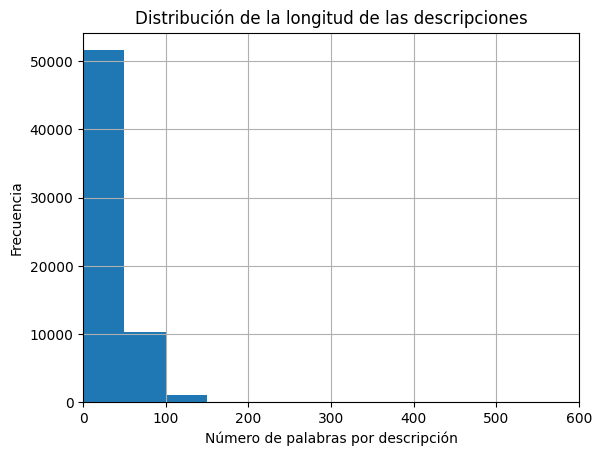

In [40]:
def word_count(text):
    tokens = re.findall(r'\w+', str(text))
    return len(tokens)

df['word_count'] = df['texto_lematizado_pos'].apply(word_count)

plt.xlabel('Número de palabras por descripción')
plt.ylabel('Frecuencia')
plt.title('Distribución de la longitud de las descripciones')

bins = range(0, 601, 50)
df['word_count'].hist(bins=bins)

plt.xlim(0, 600)

Como vemos, la mayoría de las descripciones de la serie tienen entre 0 y 50 palabras. Hay muy pocas con más de 100. Ahora, veamos cual es la longitud media pero por genero:

,word_count
genres,
Action & Adventure,35.718957
Animation,37.275405
Comedy,32.999757
Crime,28.288894
Documentary,27.440476
Drama,33.191312
Family,30.883683
History,27.500000
Kids,27.814924


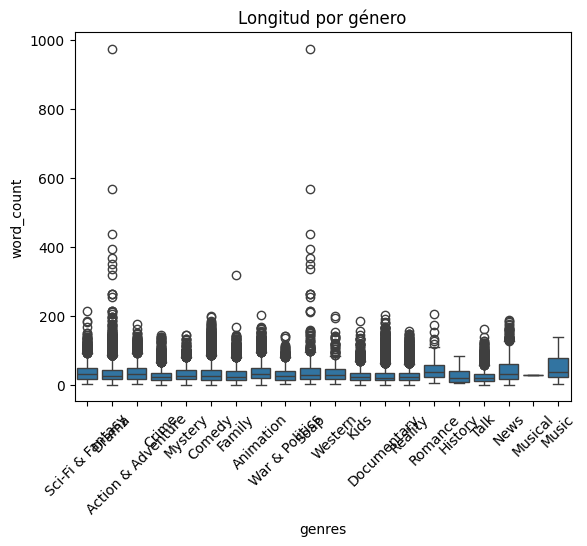

In [41]:
import seaborn as sns

df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres').reset_index(drop=True)

display(df_exploded.groupby('genres')['word_count'].mean())

sns.boxplot(data=df_exploded, x="genres", y="word_count")
plt.title("Longitud por género")
plt.xticks(rotation=45)
plt.show()


Hemos tenido que separar los generos, pues una serie puede tener más de un genero. Si tuviesemos en cuenta las combinaciones presentes en el dataset, no entenderiamos nada. Por eso mismo, estamos mirando por genero. Como vemos, la mayoría están entre las 30 y las 50 palabras de media. Hay muchos "outliers". Por ejemplo, en ciencia ficción y fantasia, hay una descripción de 1000 palabras. Alguien ha dado la chapa.

Veamos si el vocabulario es más rico en un genero que en otro. Vamos a volver a hacer el histograma, pero esta vez contando palabras únicas y por género. Como antes, vamos a hacer por genero, no por conjunto de géneros.

<Axes: >

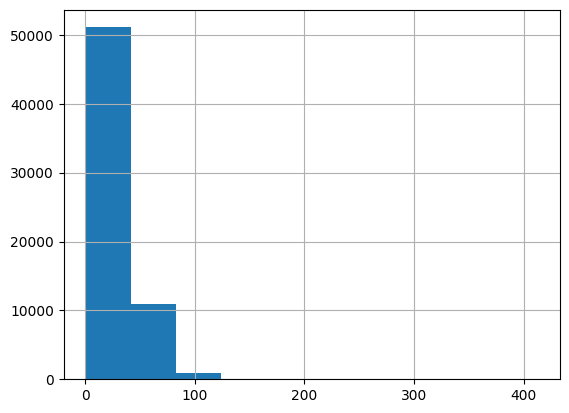

In [42]:
df['unique_word_count'] =df['texto_lematizado_pos'].apply(lambda x: len(set(str(x).split())))

df['unique_word_count'].hist()

,unique_word_count
genres,
Action & Adventure,31.727130
Animation,32.879435
Comedy,29.351287
Crime,25.953811
Documentary,25.026355
Drama,29.504017
Family,27.400377
History,25.678571
Kids,24.946880


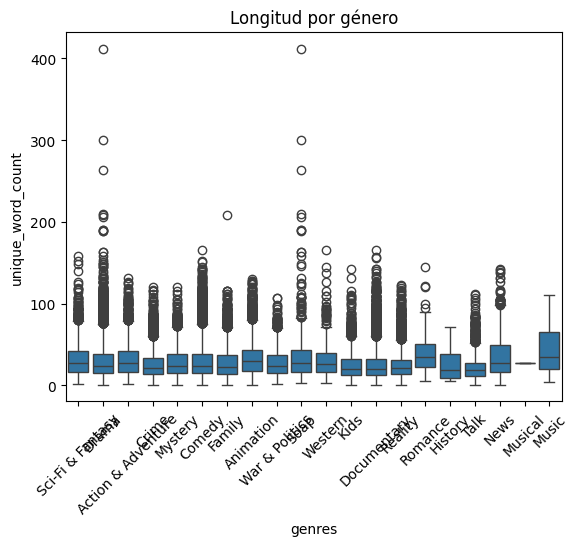

In [43]:

df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres').reset_index(drop=True)


display(df_exploded.groupby('genres')['unique_word_count'].mean())

sns.boxplot(data=df_exploded, x="genres", y="unique_word_count")
plt.title("Longitud por género")
plt.xticks(rotation=45)
plt.show()

Como vemos, esta vez hay de media unas 25/30 palabras únicas por genero. No hay ningún género que destaque especialemente, tan solo el de `Music`, pero es que este género solo tiene una entrada. Vemos que a pesar de reducirse levemente las longitudes, se siguen manteniendo las mismas tendencias que usando todas las palabras. Es decir, la mayoria de las palabras presentes en cada descripción son únicas con respecto al resto de descripciones. Esto significa que solo tenemos unas pocas palabras para identificar a qué clase pertenece cada descripción.

Empecemos por analizar el ranking de las palabras más frecuentes. Como sabemos por la teoria, en principio la segunda palabra más común debería aparece la mitad de la veces que la más común. La tercera palabra más común debería aparece un terciod e las veces que la más común... y así sucesivamente. Veamos si esto es así, primero, con la columna sin preprocesar, la columna ``overview``

### Las 30 palabras más frecuentes antes de cualquier preprocesamiento

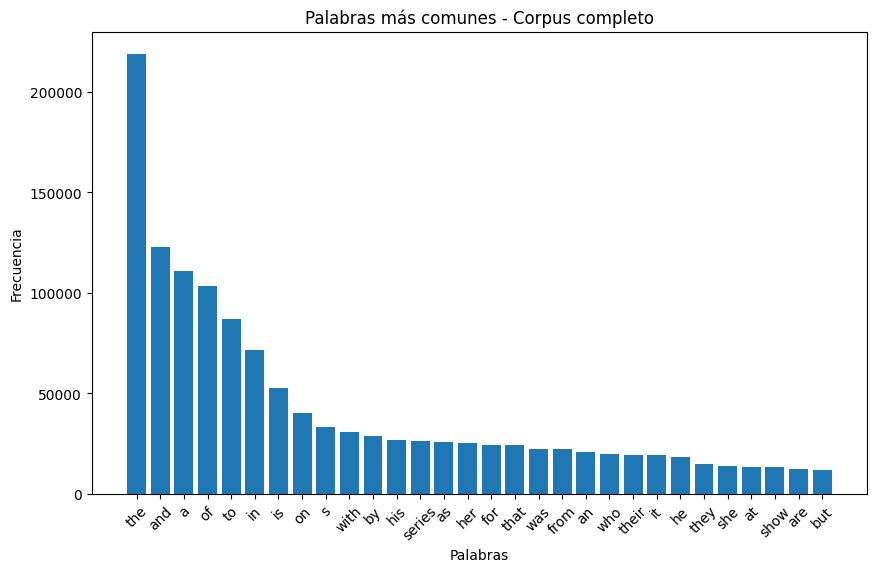

[('the', 218893),
 ('and', 123063),
 ('a', 110812),
 ('of', 103484),
 ('to', 86865),
 ('in', 71720),
 ('is', 52907),
 ('on', 40020),
 ('s', 33329),
 ('with', 30887),
 ('by', 28809),
 ('his', 26960),
 ('series', 26541),
 ('as', 25668),
 ('her', 25108),
 ('for', 24541),
 ('that', 24301),
 ('was', 22518),
 ('from', 22172),
 ('an', 20738),
 ('who', 19848),
 ('their', 19481),
 ('it', 19273),
 ('he', 18205),
 ('they', 14778),
 ('she', 13789),
 ('at', 13541),
 ('show', 13438),
 ('are', 12564),
 ('but', 11779)]

In [44]:
# Unir todos los textos
texts = df["overview"].dropna().astype(str).tolist()

# Tokenización
words = [
    w for text in texts
    for w in re.findall(r"\b\w+\b", text.lower())
]

# Conteo global
word_counts = Counter(words)

# Top 10 global
top_words = word_counts.most_common(30)

# Separar palabras y frecuencias
words, counts = zip(*top_words)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.title("Palabras más comunes - Corpus completo")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)
plt.show()

# Ranking por si lo quieres ver
top_words

Como vemos, las primeras 30 palabras mas frecuentes antes de hacer ningún preprocesamiento al texto como tal son, en su mayoría, StopWords comunes (como ``the``, ``and``...) y StopWords de contexto (``show``..).

Ahora, veamos las palabras más comunes por genero, para ver si de forma visual vemos algún tipo de relación.

In [47]:
from collections import Counter

# --- Explode ---
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres').reset_index(drop=True)

rankings = {}

for label in df_exploded["genres"].dropna().unique():
    texts = df_exploded[df_exploded["genres"] == label]["texto_lematizado_pos"].dropna().astype(str).tolist()
    words = [word for text in texts for word in text.lower().split() if word]
    word_counts = Counter(words)
    rankings[label] = word_counts.most_common(10)

rankings

{'Sci-Fi & Fantasy': [('human', 717),
  ('power', 681),
  ('earth', 638),
  ('mysterious', 570),
  ('fight', 502),
  ('call', 485),
  ('force', 443),
  ('must', 432),
  ('evil', 416),
  ('use', 401)],
 'Drama': [('love', 2261),
  ('father', 1907),
  ('family', 1866),
  ('mother', 1733),
  ('start', 1543),
  ('high', 1498),
  ('daughter', 1486),
  ('together', 1463),
  ('try', 1445),
  ('fall', 1443)],
 'Action & Adventure': [('fight', 678),
  ('adventure', 607),
  ('power', 603),
  ('force', 515),
  ('call', 495),
  ('human', 474),
  ('team', 472),
  ('earth', 464),
  ('use', 460),
  ('mysterious', 439)],
 'Crime': [('crime', 1201),
  ('murder', 1129),
  ('police', 1117),
  ('case', 1109),
  ('detective', 925),
  ('criminal', 587),
  ('investigation', 461),
  ('solve', 423),
  ('killer', 398),
  ('team', 382)],
 'Mystery': [('case', 711),
  ('murder', 632),
  ('detective', 609),
  ('mystery', 489),
  ('police', 464),
  ('crime', 441),
  ('mysterious', 413),
  ('secret', 388),
  ('solve

A simple vista, sí que parecen verse palabras clave que coinciden con el genero. Por ejemplo, en `History`, la palabra mas común es history, king, empire... palabras que tienen mucho que ver con la historia. Tiene buena pinta. Ahora, veamos un gráfico de barras para verlo de forma visual.

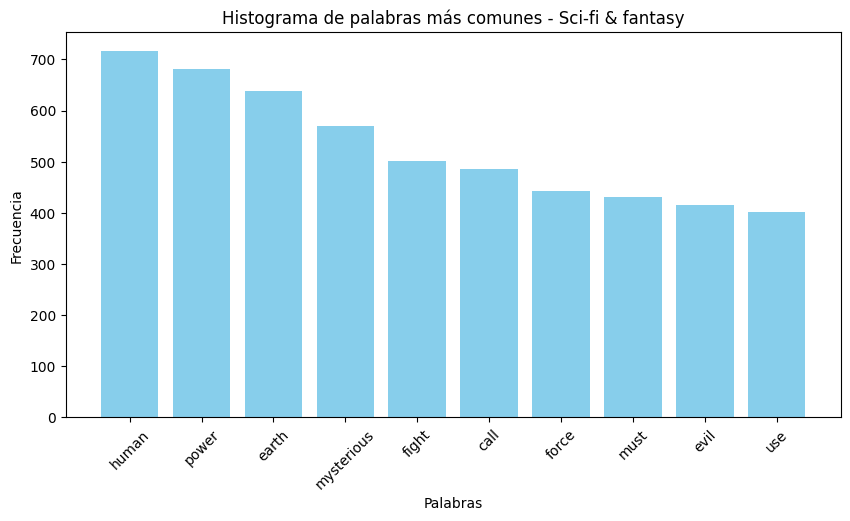

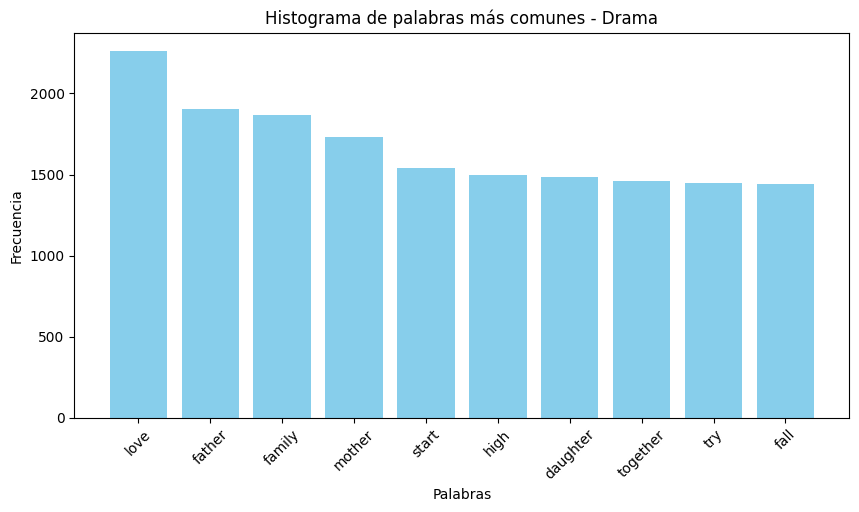

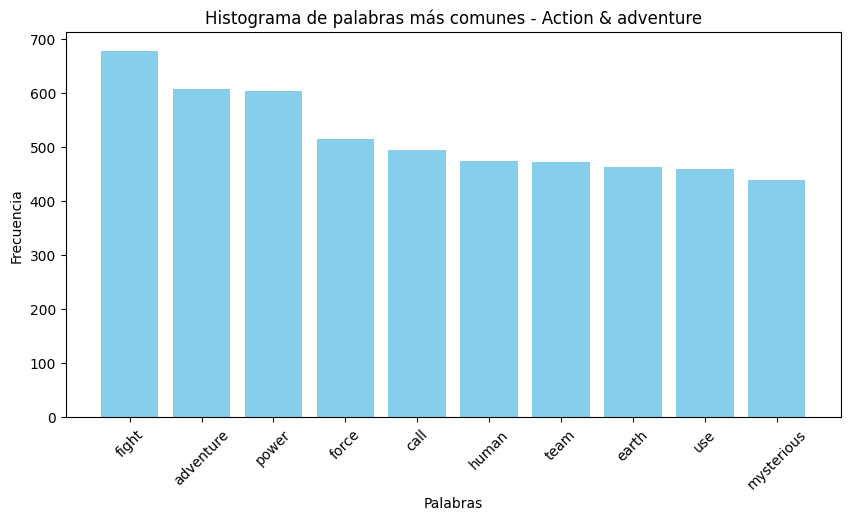

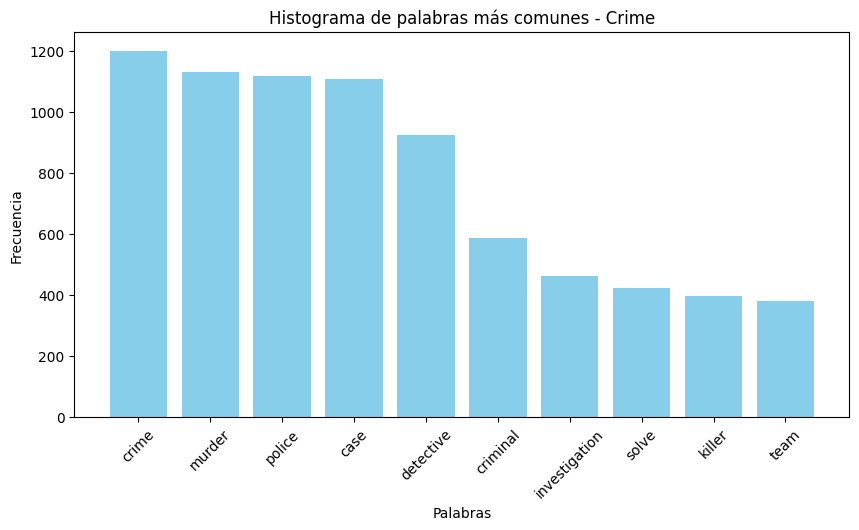

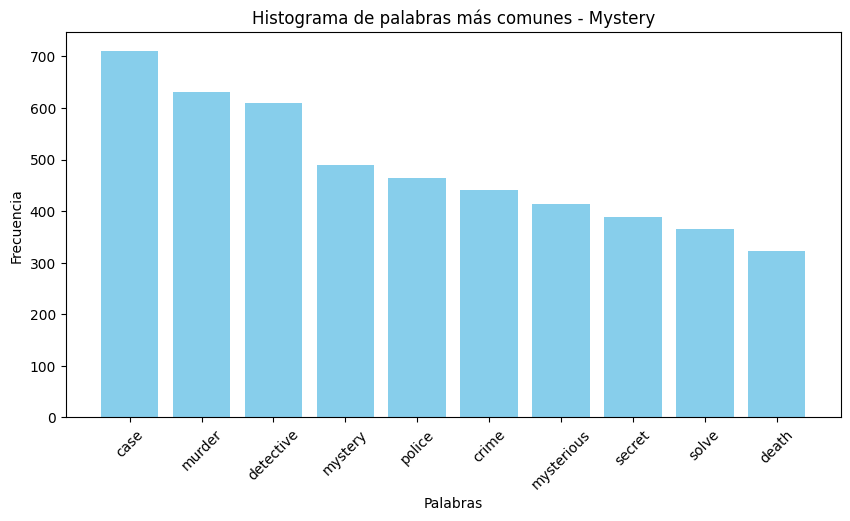

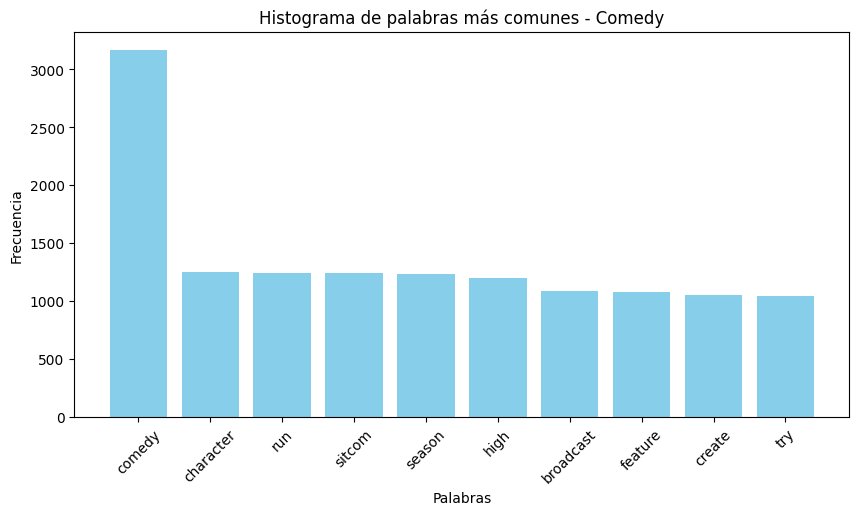

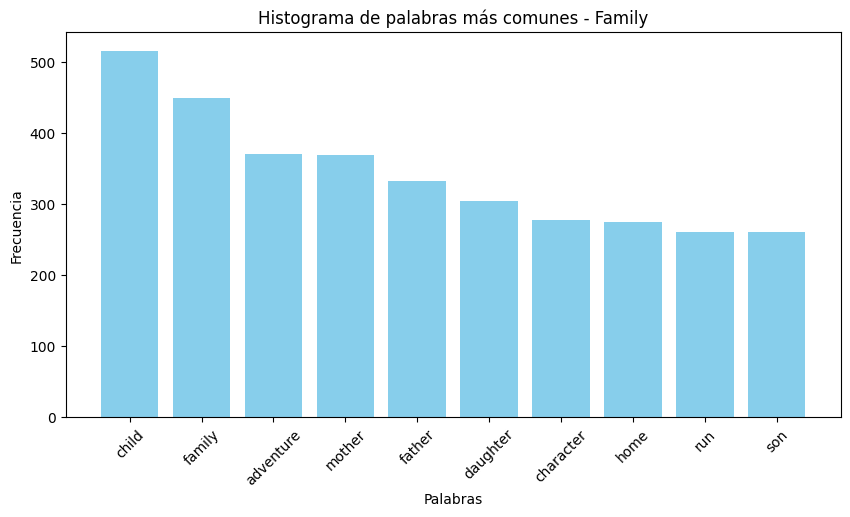

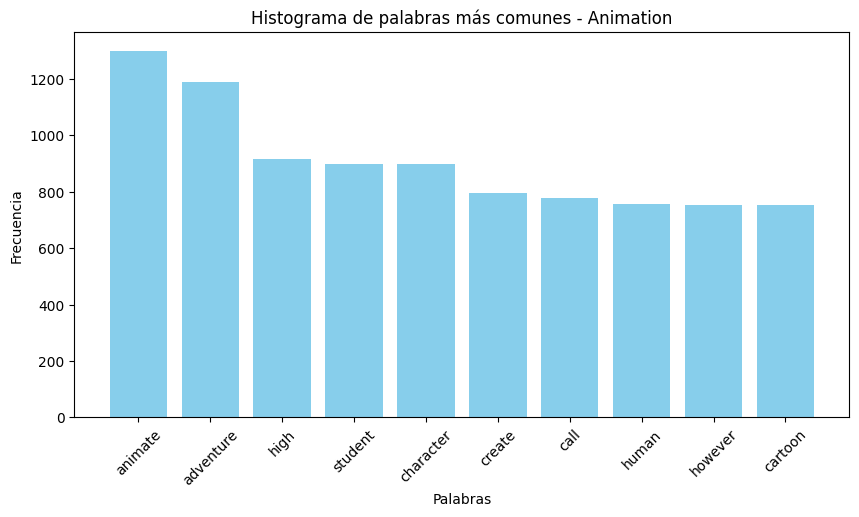

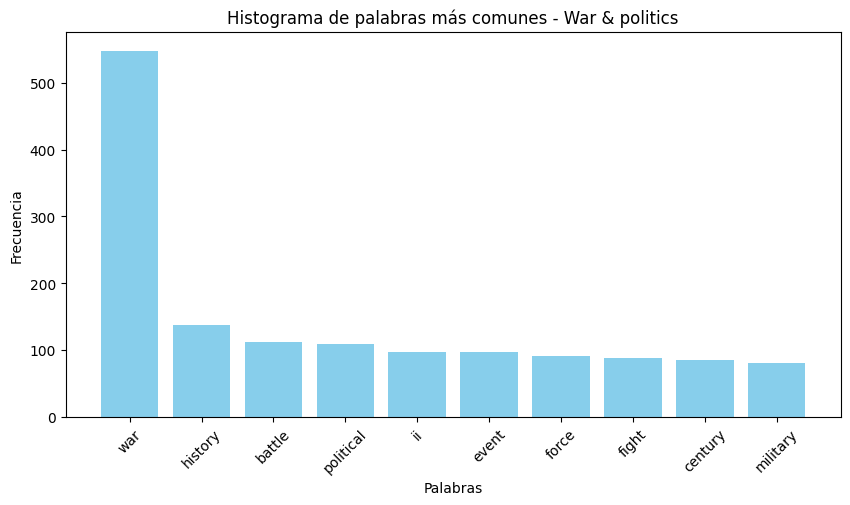

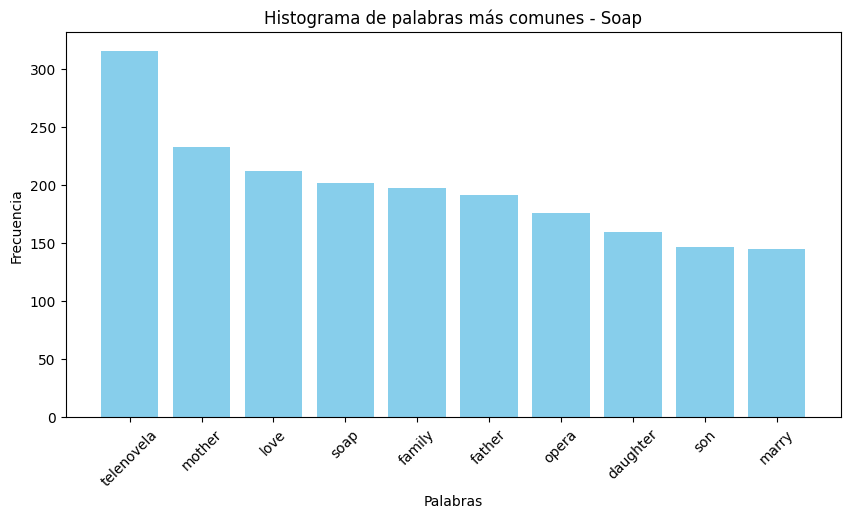

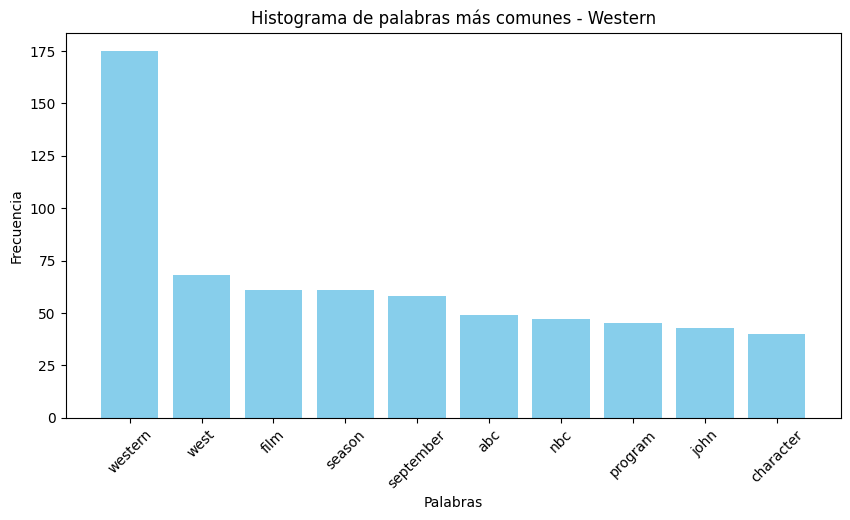

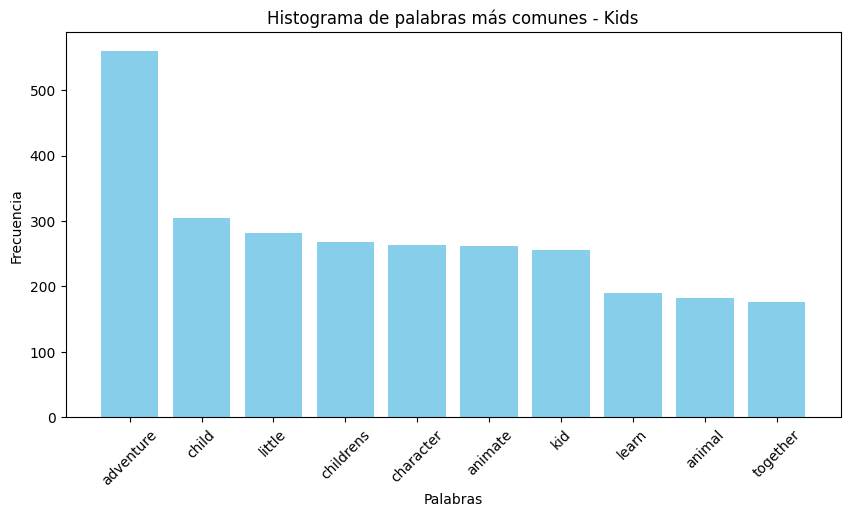

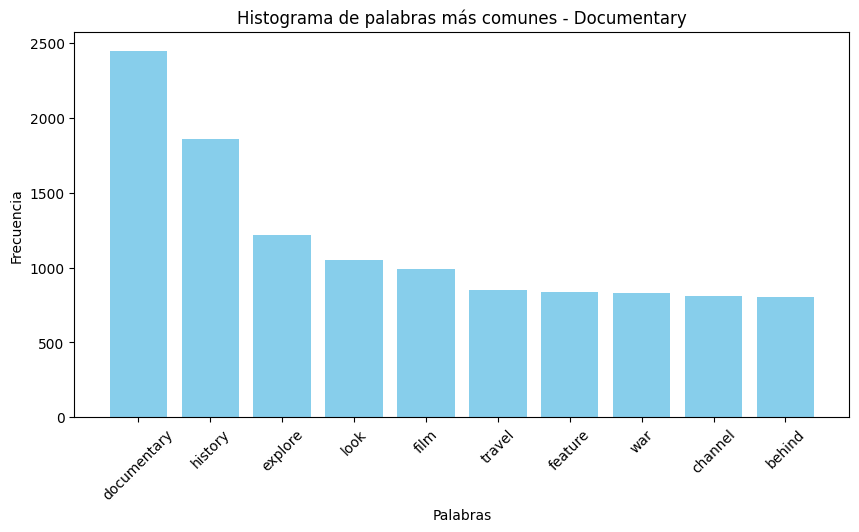

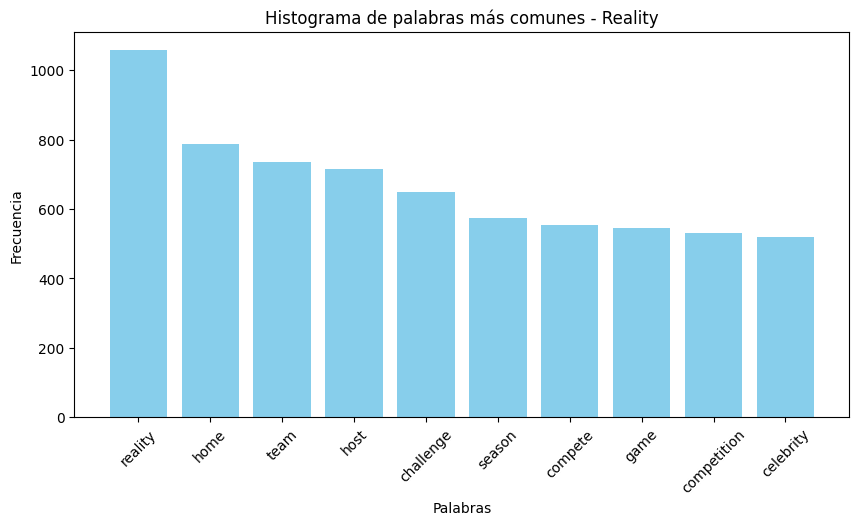

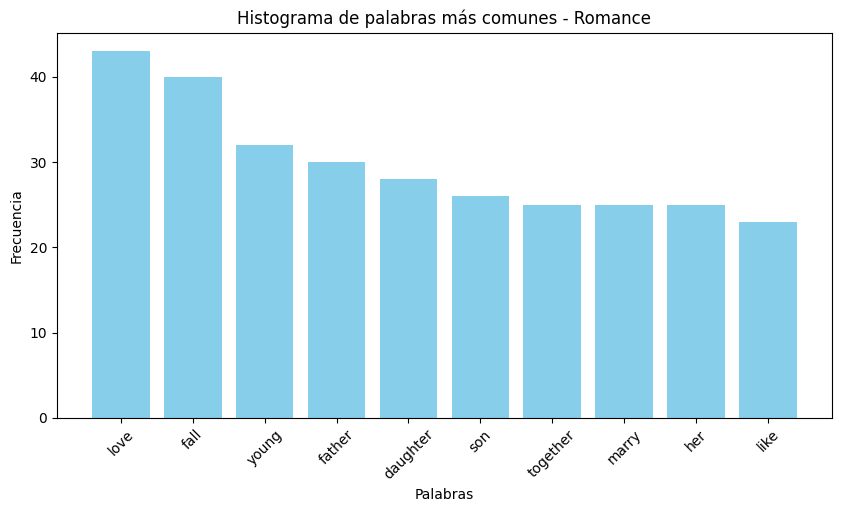

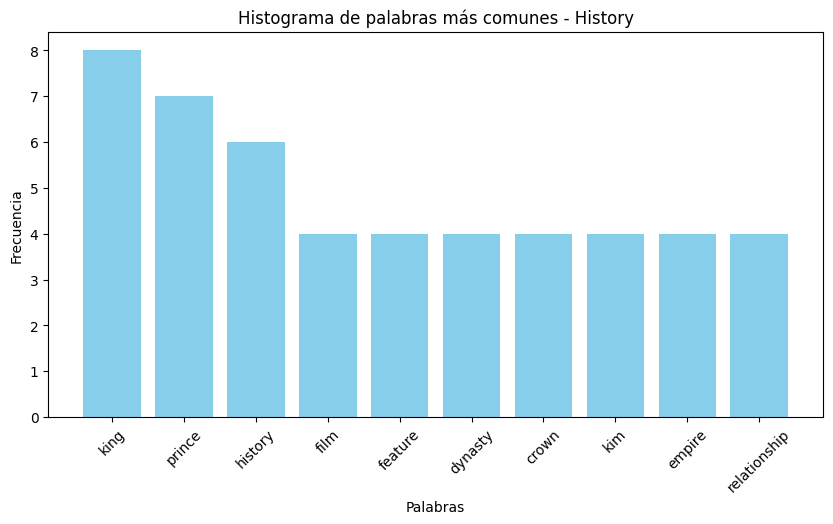

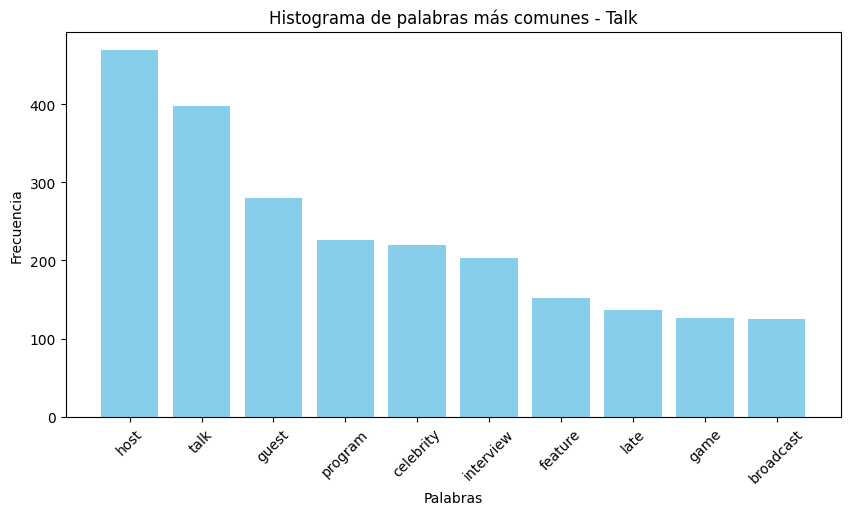

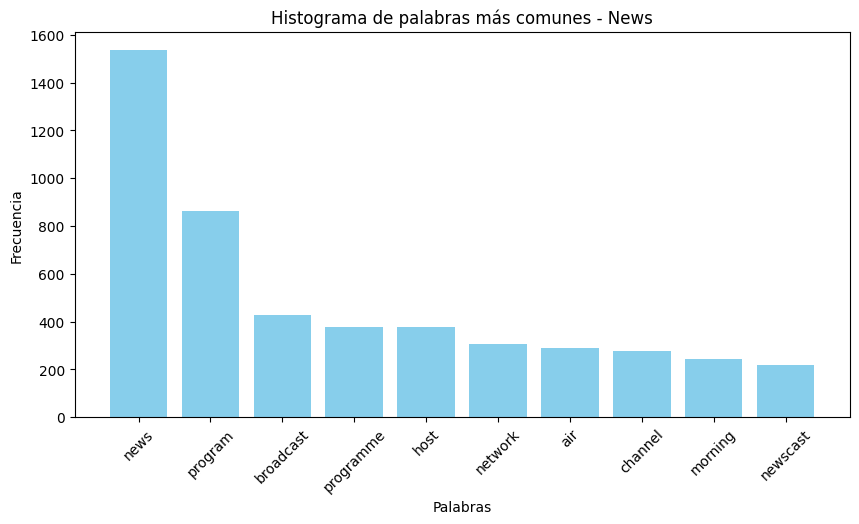

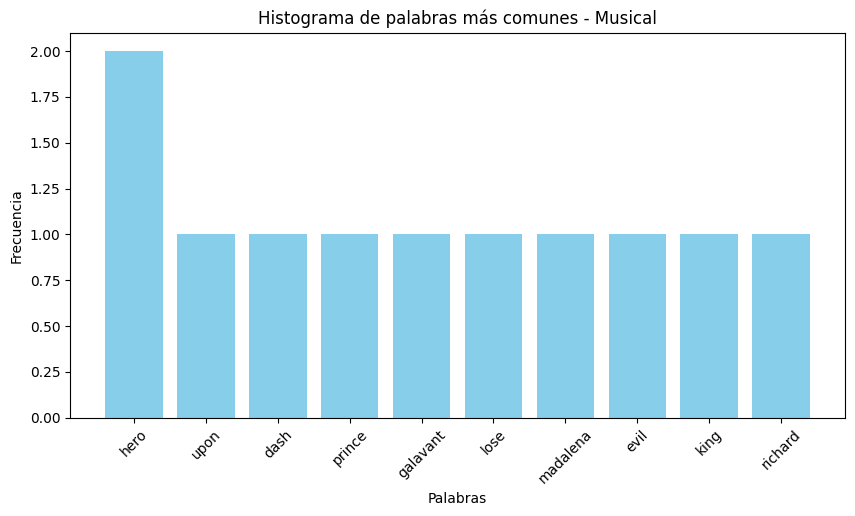

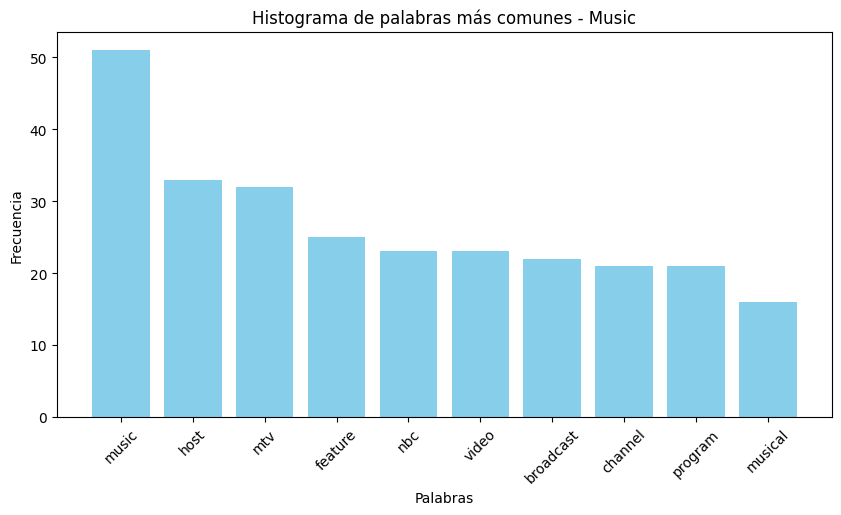

In [48]:
def plot_histogram(word_counts, history):
    words, counts = zip(*word_counts)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.xlabel("Palabras")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de palabras más comunes - {history.capitalize()}")
    plt.xticks(rotation=45)
    plt.show()

for history, word_counts in rankings.items():
    plot_histogram(word_counts, history)

Estos gráficos de barras confirman lo dicho. Por ejemplo, en Western una de las palabras más comunes en Jhon, problamente de Jhon Wainne.

En muchas ocasiones, para crear una representación y ahorrar recursos se omiten palabras por debajo de un umbral. En este caso, por ejemplo, vamos a considerar palabras poco frecuentes a aquellas que aparezcan una sola vez en el dataset. No obstante, al estar frente a un dataset tan pequeño, no hay muchos recursos que ahorrar. Por eso mismo, no vamos a eliminar ninguna palabra de momento.

In [49]:
from collections import Counter

# --- Explode ---
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres').reset_index(drop=True)

oov_per_label = {}

for label in df_exploded['genres'].dropna().unique():
    texts = df_exploded[df_exploded['genres'] == label]['texto_lematizado_pos']

    words = [word for text in texts for word in str(text).lower().split()]
    freq_dist = Counter(words)

    oov_words = [word for word, freq in freq_dist.items() if freq == 1]

    oov_per_label[label] = oov_words

    print(f"\nlabel: {label}")
    print("Número de oov:", len(oov_words))
    print("Algunas palabras oov:", oov_words[:20])


label: Sci-Fi & Fantasy
Número de oov: 13930
Algunas palabras oov: ['morningstar', 'visiontwo', 'idealized', 'livesbegin', 'csi', 'metahuman', 'labs', 'becomethe', 'tesseract', 'endgame', 'variance', 'variant', 'vigilantes', 'bluecollar', 'willingness', 'mentallyunbalanced', 'reconnected', 'mortys', '1864', 'returns']

label: Drama
Número de oov: 32523
Algunas palabras oov: ['coinage', 'flesheating', 'riverdales', 'gameswith', 'fearlessness', 'maximoff', 'visiontwo', 'idealized', 'livesbegin', 'metahuman', 'labs', 'tesseract', 'seattles', '1864', 'bucky', 'expendable', 'habitable', 'otis', 'maeve', 'lothbrok']

label: Action & Adventure
Número de oov: 15183
Algunas palabras oov: ['westeros', 'flesheating', 'gameswith', 'tempt', 'bluecollar', 'willingness', 'mentallyunbalanced', 'reconnected', 'mortys', 'returns', 'konoha', 'amassed', 'radioactivity', 'expendable', 'lothbrok', 'sagas', 'ragnars', 'devotion', 'reignites', 'larusso']

label: Crime
Número de oov: 10969
Algunas palabras oo

In [50]:
oov = sum(1 for word, freq in freq_dist.items() if freq == 1)
print("% de palabras únicas en todo el vocabulario ratio:", oov / len(freq_dist))

% de palabras únicas en todo el vocabulario ratio: 0.6456043956043956


In [51]:
oov_words = [word for word, freq in freq_dist.items() if freq == 1]
print("Palabras que aparecen solo una vez:", oov_words[:20])

Palabras que aparecen solo una vez: ['opera', 'miniseries', 'adapt', 'arthur', 'kopits', 'thenunproduced', 'loosely', 'gaston', 'lerouxs', 'novel', 'un', 'paso', 'adelante', 'fame', 'antena', '2002', 'huge', 'spanishspeaking', 'italy', 'serbia']


---
## Tarea 2.2. Preprocesamiento de Texto para BertTopic <a id='2'></a>


El preprocesamiento para LDA/NFM ya se ha hecho a lo largo del EDA. Por lo tanto, haremos el del BERTopic muy por encima de momento.

In [52]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

def preprocess_bert(text):
    """BERTopic prefiere texto natural — solo limpieza básica."""
    text = re.sub(r'\S+@\S+', '', text)   # emails
    text = re.sub(r'http\S+', '', text)    # URLs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Preprocesando documentos...')

df["overview_BERT"] = df["overview"].apply(preprocess_bert)

Preprocesando documentos...


---
## Tarea 2.3.1. LDA — Latent Dirichlet Allocation <a id='3'></a>

LDA modela cada documento como una **mezcla de tópicos** y cada tópico como una distribución de palabras.
Es el baseline clásico, rápido e interpretable. Requiere fijar `n_components` manualmente. Como no sabemos n_components, vamos a buscarlos basandonos en el Coherence Score. Vamos a recorrer todos los valores de N entre 10 y 30, y luego, en principio, cogeremos el que mayor Coherence Score tenga. Además, para la búsqueda y creación del mejor modelo, usaremos el texto preprocesado, que como hemos ido haciendo en las celdas de arriba, corresponde a la columna de ``texto_lematizado_pos``.


In [53]:
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, LdaMulticore
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)


In [54]:
documents = [str(text).split() for text in df['texto_lematizado_pos']]

dictionary = corpora.Dictionary(documents)

corpus = [dictionary.doc2bow(doc) for doc in documents]

print(f"Número de tokens únicos en el diccionario: {len(dictionary)}")
print(f"Número de documentos en el corpus: {len(corpus)}")

Número de tokens únicos en el diccionario: 115017
Número de documentos en el corpus: 63076


K=10 -> Coherencia: 0.6000
K=11 -> Coherencia: 0.5782
K=12 -> Coherencia: 0.5622
K=13 -> Coherencia: 0.5545
K=14 -> Coherencia: 0.5411
K=15 -> Coherencia: 0.5478
K=16 -> Coherencia: 0.5370
K=17 -> Coherencia: 0.5539
K=18 -> Coherencia: 0.5638
K=19 -> Coherencia: 0.5542
K=20 -> Coherencia: 0.5535
K=21 -> Coherencia: 0.4897
K=22 -> Coherencia: 0.5084
K=23 -> Coherencia: 0.4892
K=24 -> Coherencia: 0.4949
K=25 -> Coherencia: 0.5194
K=26 -> Coherencia: 0.4858
K=27 -> Coherencia: 0.4955
K=28 -> Coherencia: 0.5048
K=29 -> Coherencia: 0.5092
K=30 -> Coherencia: 0.4874


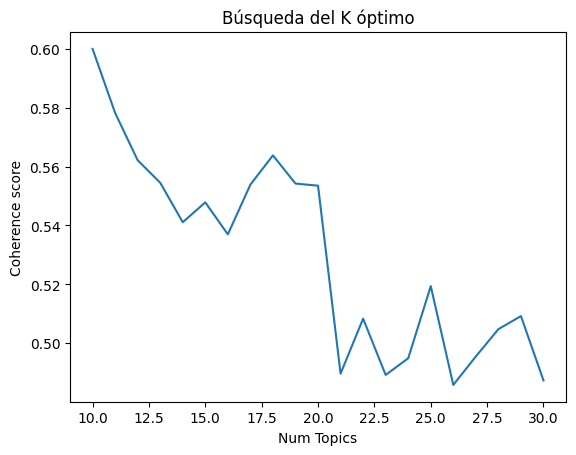

Mejor número de temas: 10


In [ ]:
def evaluate_graph(dictionary, corpus, texts, limit):
    c_scores = []
    models = []
    for k in range(10, limit + 1, 1):
        model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10)
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        c_scores.append(coherence_model.get_coherence())
        models.append(model)
        print(f"K={k} -> Coherencia: {c_scores[-1]:.4f}")
    return models, c_scores

limit_k = 30
models, scores = evaluate_graph(dictionary, corpus, documents, limit_k)

plt.plot(range(10, limit_k + 1), scores)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.title("Búsqueda del K óptimo")
plt.show()

best_index = np.argmax(scores)
lda_model = models[best_index]
print(f"Mejor número de temas: {(best_index + 10)}")

Como vemos, el modelo con el número de topics = 10 es el que tiene el Coherence Score más alto. En el análisis que sigue, veremos si los tópics están bien separados o no. El coherence Score es de 0.6.

La celda de código de abajo se pone a fin de no tener que volver a ejecutar la celda de arriba nuevamente, pues tarda mucho tiempo en ejecutarse. Sabiendo cual es el N_Topics óptimo, podemos cargar el modelo directamente con esa N.

In [55]:
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=10, random_state=42, passes=10)

In [56]:
# =========================
# 1. TOP-10 palabras de cada tópico
# =========================

topics_words = lda_model.show_topics(
    num_topics=lda_model.num_topics,
    num_words=10,
    formatted=False
)

for topic_id, words in topics_words:
    print(f"\nTópico {topic_id}")
    print(", ".join([word for word, weight in words]))


Tópico 0
human, animal, adventure, earth, power, fight, planet, battle, hero, island

Tópico 1
student, high, teacher, college, class, university, sex, india, manager, club

Tópico 2
case, crime, police, murder, detective, mystery, secret, criminal, investigation, behind

Tópico 3
documentary, history, explore, war, look, u, country, great, canadian, tell

Tópico 4
game, team, music, celebrity, australian, challenge, host, big, reality, win

Tópico 5
food, travel, home, chef, uk, cook, visit, car, presenter, across

Tópico 6
program, broadcast, news, network, channel, season, host, air, feature, film

Tópico 7
doctor, hospital, south, korean, dr, medical, park, sing, lee, patient

Tópico 8
love, family, father, try, child, mother, relationship, together, start, want

Tópico 9
programme, new, british, nbc, cbs, indian, york, adventure, comedy, john


Si analizamos los tópicos e intentamos etiquetarlos, podemos conseguir los siguiente:

- Tópico 0: Por las palabras que lo componen, podría ser una mezcla entre algo de animal y algo de acción. ``Acción``

- Tópico 1: Por las palabras, parecen dramas estudiantiles. Tipicias series para gente de la ESO. ``Drama Estudiantil``

- Tópico 2: Parecen seríes policiacas y de investigación tipo CSI. ``Policiacas``

- Tópico 3: Parecen series documentales de historia, sobre guerras y temas antiguos. ``Documentales Históricos``

- Topico 4: Parece series de realitis show y concursos tipo Wipe Out. ``Realitys``

- Topic 5: Parecen series sore viajes y comida como Arguiñano o Viajeros Cuatro. ``Viaje``

- Tópico 6: Parecen series sobre noticias y tertulianos. ``Noticias y Tertulias``

- Tópico 7: Parecen series sobre médicos tipo Anatomia de Grey. ``Medicina``

- Tópico 8: Parecen series sobre familias y dramas familiares. ``Familiar``

- Tópico 9: Parecen series sobre noticias otra vez pero mezcladoc on comedia. A lo mejor programas tipo El Intermedio. ``Late Talk``.

In [80]:
# =========================
# ETIQUETAS MANUALES LDA
# =========================

lda_topic_labels = {
    0: "Acción",
    1: "Drama Estudiantil",
    2: "Policiacas",
    3: "Documentales Históricos",
    4: "Realitys",
    5: "Viaje",
    6: "Noticias y Tertulias",
    7: "Medicina",
    8: "Familiar",
    9: "Late Talk"
}

A continuación, sigamos con NMF.

---
## Tarea 2.3.2. NMF — Non-negative Matrix Factorization <a id='4'></a>

NMF con TF-IDF produce tópicos más limpios que LDA en la mayoría de benchmarks.

Matriz TF-IDF: (63076, 46253)
Documentos usados para c_v: 3000
K=10 -> Coherencia c_v: 0.5045
K=11 -> Coherencia c_v: 0.4920
K=12 -> Coherencia c_v: 0.4926
K=13 -> Coherencia c_v: 0.4698
K=14 -> Coherencia c_v: 0.4661
K=15 -> Coherencia c_v: 0.4643
K=16 -> Coherencia c_v: 0.4457
K=17 -> Coherencia c_v: 0.4472
K=18 -> Coherencia c_v: 0.4621
K=19 -> Coherencia c_v: 0.4622
K=20 -> Coherencia c_v: 0.4316
K=21 -> Coherencia c_v: 0.4417
K=22 -> Coherencia c_v: 0.4296
K=23 -> Coherencia c_v: 0.4225
K=24 -> Coherencia c_v: 0.4152
K=25 -> Coherencia c_v: 0.4272
K=26 -> Coherencia c_v: 0.4248
K=27 -> Coherencia c_v: 0.4184
K=28 -> Coherencia c_v: 0.4360
K=29 -> Coherencia c_v: 0.4217
K=30 -> Coherencia c_v: 0.4416


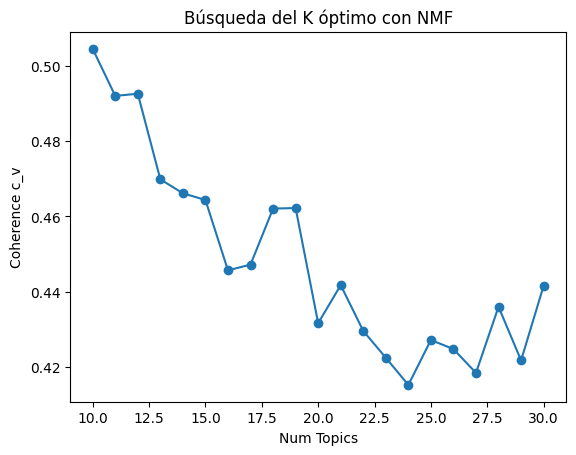

Mejor número de temas NMF según c_v: 10
Mejor coherencia c_v: 0.5045


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. DOCUMENTOS
# =========================

documents_str = [
    " ".join(doc) if isinstance(doc, list) else str(doc)
    for doc in documents
]

texts_nmf = [
    doc if isinstance(doc, list) else str(doc).split()
    for doc in documents
]


# =========================
# 2. TF-IDF
# =========================

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words=None,
    ngram_range=(1, 1)
)

X_tfidf = tfidf_vectorizer.fit_transform(documents_str)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("Matriz TF-IDF:", X_tfidf.shape)


# =========================
# 3. MUESTRA PARA C_V
# =========================

MAX_DOCS_CV = 3000

texts_nmf_cv = texts_nmf[:MAX_DOCS_CV]
dictionary_nmf_cv = Dictionary(texts_nmf_cv)

print("Documentos usados para c_v:", len(texts_nmf_cv))


# =========================
# 4. EVALUAR NMF CON C_V
# =========================

def evaluate_nmf_cv(
    X_tfidf,
    texts_cv,
    dictionary_cv,
    feature_names,
    start=10,
    limit=30,
    top_n_words=10
):
    c_scores = []
    models = []
    tested_ks = []

    for k in range(start, limit + 1):

        model = NMF(
            n_components=k,
            random_state=42,
            init="nndsvda",
            max_iter=300
        )

        model.fit(X_tfidf)

        topics_words = []

        for topic in model.components_:
            top_indices = topic.argsort()[::-1][:top_n_words]
            topic_words = [feature_names[i] for i in top_indices]
            topics_words.append(topic_words)

        coherence_model = CoherenceModel(
            topics=topics_words,
            texts=texts_cv,
            dictionary=dictionary_cv,
            coherence="c_v",
            processes=1
        )

        cv_score = coherence_model.get_coherence()

        c_scores.append(cv_score)
        models.append(model)
        tested_ks.append(k)

        print(f"K={k} -> Coherencia c_v: {cv_score:.4f}")

    return models, c_scores, tested_ks


models_nmf, scores_nmf, tested_ks = evaluate_nmf_cv(
    X_tfidf=X_tfidf,
    texts_cv=texts_nmf_cv,
    dictionary_cv=dictionary_nmf_cv,
    feature_names=feature_names,
    start=10,
    limit=30,
    top_n_words=10
)


# =========================
# 5. GRÁFICO
# =========================

plt.plot(tested_ks, scores_nmf, marker="o")
plt.xlabel("Num Topics")
plt.ylabel("Coherence c_v")
plt.title("Búsqueda del K óptimo con NMF")
plt.show()


# =========================
# 6. MEJOR MODELO
# =========================

best_index = np.argmax(scores_nmf)

best_k_nmf = tested_ks[best_index]
nmf_model = models_nmf[best_index]

print(f"Mejor número de temas NMF según c_v: {best_k_nmf}")
print(f"Mejor coherencia c_v: {scores_nmf[best_index]:.4f}")

Como vemos arriba, el mejor número de Tópicos es 10, como en LDA, con un Coherence Score de 0.50.

En este caso, hemos utilizado menos palabras para calcular el Coherence Score, porque si no el sistema se quedaba sin memoria no sé muy bien por qué.


In [58]:
# =========================
# TOP-10 PALABRAS POR TÓPICO
# =========================

def print_nmf_topics(model, feature_names, n_words=10):

    for topic_idx, topic in enumerate(model.components_):

        top_indices = topic.argsort()[::-1][:n_words]

        top_words = [
            feature_names[i]
            for i in top_indices
        ]

        print("=" * 80)
        print(f"Tópico {topic_idx}")
        print(", ".join(top_words))


print_nmf_topics(
    model=nmf_model,
    feature_names=feature_names,
    n_words=10
)

Tópico 0
love, family, father, mother, child, daughter, relationship, son, try, fall
Tópico 1
season, broadcast, network, september, premier, channel, film, air, run, sitcom
Tópico 2
german, die, der, und, da, ein, familie, von, war, germany
Tópico 3
case, police, crime, murder, detective, solve, investigation, criminal, officer, investigate
Tópico 4
documentary, history, war, explore, look, film, british, event, tell, present
Tópico 5
game, team, challenge, compete, celebrity, reality, win, host, contestant, competition
Tópico 6
news, program, host, programme, broadcast, morning, current, talk, pm, air
Tópico 7
comedy, sketch, comedian, standup, feature, situation, character, british, guest, variety
Tópico 8
student, high, group, teacher, college, class, club, member, university, academy
Tópico 9
adventure, human, animal, earth, little, power, journey, travel, city, fight


Repitiendo el procedimiento de antes, vamos a intentar etiquetar manualmente cada tópico en función de las palabras más importantes de cada uno.


- Topic 0: Algo familiar. ``Familiar``.

- Topic 1: Parece algo de noticias o algo por el estilo. ``News``.

- Topic 2: Alemán. ``Aleman``.

- Topic 3: ``Policiacas``.

- Topic 4: ``Documental Historico``

- Topic 5: ``Reality Show``-

- Topic 6: ``News`` otra vez.

- Topic 7: ``Comedia``

- Topic 8: ``Drama estudiantil``

- Topic 9: ``Acción``.

In [82]:
nmf_topic_labels = {
    0: "Familiar",
    1: "News",
    2: "Alemán",
    3: "Policiacas",
    4: "Documental Histórico",
    5: "Reality Show",
    6: "News",
    7: "Comedia",
    8: "Drama Estudiantil",
    9: "Acción"
}

---
## Tarea 2.4. BERTopic — Embeddings Neurales <a id='5'></a>

BERTopic combina embeddings semánticos con clustering denso.
**No requiere especificar el número de tópicos a priori.**


In [59]:
# =========================
# IMPORTS
# =========================

import nltk
from nltk.corpus import stopwords

from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN

nltk.download("stopwords", quiet=True)

True

In [60]:
# =========================
# DOCUMENTOS PARA BERTOPIC
# =========================

docs_bert = (
    df["overview_BERT"]
    .fillna("")
    .astype(str)
    .str.strip()
)

docs_bert = docs_bert[docs_bert != ""].tolist()

print("Número de documentos:", len(docs_bert))

Número de documentos: 63076


In [61]:
# =========================
# CONFIGURACIÓN MODULAR BERTOPIC
# =========================

# 1. Modelo de embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Reducción de dimensionalidad
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# 3. Clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# 4. Representaciones base
representation_base = {
    "KeyBERT": KeyBERTInspired(),
    "MMR": MaximalMarginalRelevance(diversity=0.4)
}

print("Pipeline BERTopic configurado")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Pipeline BERTopic configurado


Basandonos en celdas anterior, las StopWords custom son las de la lista de abajo. Estas son palabras que consideramos muy genericas para el dominio con el que estamos trabajando.

In [62]:
# =========================
# VECTORIZADOR + C-TF-IDF
# =========================

stop_en = set(stopwords.words("english"))

custom_stops = {
    "series", "show", "television", "one", "life", "new",
    "first", "aired", "story", "two", "also", "love",
    "family", "young", "world", "produced", "american",
    "people", "lives", "drama", "around",
    "episode", "take", "year", "make", "find", "time",
    "get", "work", "follow", "become", "go", "star",
    "live", "friend", "day", "school", "girl", "woman",
    "come", "begin", "know", "meet", "name", "set",
    "base", "feature", "help", "run", "together",
    "create"
}

all_stops = stop_en | custom_stops

vectorizer = CountVectorizer(
    stop_words=list(all_stops),
    ngram_range=(1, 2),
    min_df=1,
    max_df=1.0
)

ctfidf_model = ClassTfidfTransformer(
    bm25_weighting=True,
    reduce_frequent_words=True
)

In [63]:
# =========================
# ENTRENAMIENTO
# =========================

# Para explorar rápido:
sample_docs = docs_bert[:5000]

# Para dataset completo:
# sample_docs = docs_bert

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    top_n_words=10,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(sample_docs)

print("BERTopic entrenado correctamente")

2026-05-15 15:40:08,947 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-05-15 15:40:10,277 - BERTopic - Embedding - Completed ✓
2026-05-15 15:40:10,278 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-15 15:40:24,543 - BERTopic - Dimensionality - Completed ✓
2026-05-15 15:40:24,544 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 15:40:24,715 - BERTopic - Cluster - Completed ✓
2026-05-15 15:40:24,715 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-15 15:40:25,020 - BERTopic - Representation - Completed ✓
2026-05-15 15:40:25,021 - BERTopic - Topic reduction - Reducing number of topics
2026-05-15 15:40:25,025 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 15:40:25,353 - BERTopic - Representation - Completed ✓
2026-05-15 15:40:25,355 - BERTopic - Topic reduction - Reduced number of topics from 15 to 10


BERTopic entrenado correctamente


In [64]:
# =========================
# ACTUALIZAR REPRESENTACIONES
# =========================

topic_model.update_topics(
    sample_docs,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    representation_model=representation_base
)

# TAREA 2.5: Etiquetación automática con LLM.

In [65]:
# =========================
# TAREA 5 — ETIQUETAS AUTOMÁTICAS CON LLM LOCAL
# =========================

import re
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

In [66]:
# =========================
# CARGA DEL LLM LOCAL
# =========================

LLM_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer_llm = AutoTokenizer.from_pretrained(
    LLM_MODEL_ID
)

model_llm = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

label_generator = pipeline(
    "text-generation",
    model=model_llm,
    tokenizer=tokenizer_llm,
    max_new_tokens=25,
    do_sample=False,
    return_full_text=False
)

print("LLM cargado correctamente:", LLM_MODEL_ID)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


LLM cargado correctamente: Qwen/Qwen2.5-1.5B-Instruct


In [67]:
# =========================
# FUNCIONES AUXILIARES
# =========================

def clean_llm_label(label):
    label = label.strip()
    label = label.split("\n")[0]

    label = re.sub(
        r"^(label|topic label|etiqueta|tema)\s*:\s*",
        "",
        label,
        flags=re.IGNORECASE
    )

    label = label.strip(" .:-_\"'")
    label = " ".join(label.split())

    words = label.split()

    if len(words) > 8:
        label = " ".join(words[:8])

    return label


def build_topic_prompt(topic_id, topic_words, example_docs):
    docs_text = "\n".join(
        [
            f"- {doc[:350]}"
            for doc in example_docs
        ]
    )

    prompt = f"""
You are labeling topics from a TV series dataset.

Topic ID:
{topic_id}

Top words:
{", ".join(topic_words)}

Representative documents:
{docs_text}

Generate one short natural language label for this topic.
The label must be between 2 and 6 words.
Do not explain anything.
Return only the label.
"""

    return prompt.strip()


def generate_label_for_topic(topic_id, topic_words, example_docs):
    prompt = build_topic_prompt(
        topic_id=topic_id,
        topic_words=topic_words,
        example_docs=example_docs
    )

    messages = [
        {
            "role": "system",
            "content": "You generate short, clear topic labels. Return only the label."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = tokenizer_llm.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    output = label_generator(
        formatted_prompt,
        max_new_tokens=25,
        do_sample=False,
        return_full_text=False
    )[0]["generated_text"]

    return clean_llm_label(output)

In [68]:
# =========================
# GENERAR ETIQUETAS PARA CADA TÓPICO
# =========================

topic_info = topic_model.get_topic_info()

topic_ids = (
    topic_info[topic_info["Topic"] != -1]["Topic"]
    .tolist()
)

topic_labels = {}

for topic_id in topic_ids:

    topic_words = [
        word
        for word, score in topic_model.get_topic(topic_id)[:10]
    ]

    example_docs = [
        doc
        for doc, topic in zip(sample_docs, topics)
        if topic == topic_id
    ][:3]

    label = generate_label_for_topic(
        topic_id=topic_id,
        topic_words=topic_words,
        example_docs=example_docs
    )

    topic_labels[topic_id] = label

    print(f"Tópico {topic_id} -> {label}")


# Etiqueta para outliers
topic_labels[-1] = "Outliers"

Tópico 0 -> Telenovela Mystery Series
Tópico 1 -> Anime Series - World Conflict & Supernatural Adventures
Tópico 2 -> Loki Adventures
Tópico 3 -> Apocalypse Survival Mission
Tópico 4 -> Late Night Comedy Series
Tópico 5 -> Frank Herbert's Dune Anthology
Tópico 6 -> High School Drama Romance Thriller
Tópico 7 -> Crime drama series
Tópico 8 -> Gordon Ramsay Chef Competition


In [69]:
# =========================
# REGISTRAR ETIQUETAS EN BERTOPIC
# =========================

topic_model.set_topic_labels(topic_labels)

print("Etiquetas registradas correctamente.")

Etiquetas registradas correctamente.


In [70]:
# =========================
# GUARDAR ETIQUETAS
# =========================

df_topic_labels = pd.DataFrame(
    [
        {
            "Topic": topic_id,
            "LLM_Label": label
        }
        for topic_id, label in topic_labels.items()
    ]
).sort_values("Topic")

df_topic_labels.to_csv(
    "bertopic_llm_topic_labels.csv",
    index=False
)

df_topic_labels

,Topic,LLM_Label
9,-1,Outliers
0,0,Telenovela Mystery Series
1,1,Anime Series - World Conflict & Supernatural Adventures
2,2,Loki Adventures
3,3,Apocalypse Survival Mission
4,4,Late Night Comedy Series
5,5,Frank Herbert's Dune Anthology
6,6,High School Drama Romance Thriller
7,7,Crime drama series
8,8,Gordon Ramsay Chef Competition


## Tarea 2.6. Visualización resultados BertTopic en HTML.

Los HTML se guardarán en el entorno de ejecución de Colab.

In [71]:
# =========================
# TAREA 6 — VISUALIZACIONES BERTOPIC
# =========================

import os

output_dir = "bertopic_visualizations"
os.makedirs(output_dir, exist_ok=True)

In [72]:
# =========================
# 1. MAPA 2D DE TÓPICOS
# visualize_topics()
# =========================

fig_topics = topic_model.visualize_topics(
    custom_labels=True
)

fig_topics.write_html(
    os.path.join(output_dir, "01_visualize_topics.html")
)

print("Guardado: 01_visualize_topics.html")

Guardado: 01_visualize_topics.html


In [73]:
# =========================
# 2. BARCHART TOP PALABRAS
# visualize_barchart(top_n_topics=8)
# =========================

fig_barchart = topic_model.visualize_barchart(
    top_n_topics=8,
    n_words=10,
    custom_labels=True
)

fig_barchart.write_html(
    os.path.join(output_dir, "02_visualize_barchart_top8.html")
)

print("Guardado: 02_visualize_barchart_top8.html")

Guardado: 02_visualize_barchart_top8.html


In [74]:
# =========================
# 3. HEATMAP DE SIMILITUD ENTRE TÓPICOS
# visualize_heatmap()
# =========================

fig_heatmap = topic_model.visualize_heatmap(
    custom_labels=True
)

fig_heatmap.write_html(
    os.path.join(output_dir, "03_visualize_heatmap.html")
)

print("Guardado: 03_visualize_heatmap.html")

Guardado: 03_visualize_heatmap.html


In [75]:
# =========================
# 4. DENDROGRAMA JERÁRQUICO
# visualize_hierarchy()
# =========================

fig_hierarchy = topic_model.visualize_hierarchy(
    custom_labels=True
)

fig_hierarchy.write_html(
    os.path.join(output_dir, "04_visualize_hierarchy.html")
)

print("Guardado: 04_visualize_hierarchy.html")

Guardado: 04_visualize_hierarchy.html


In [76]:
# =========================
# COMPROBAR ARCHIVOS GENERADOS
# =========================

print("Visualizaciones guardadas en:", output_dir)

for file in os.listdir(output_dir):
    print("-", file)

Visualizaciones guardadas en: bertopic_visualizations
- 02_visualize_barchart_top8.html
- 04_visualize_hierarchy.html
- 01_visualize_topics.html
- 03_visualize_heatmap.html


## Resumen de todos los modelos.

In [83]:
# =========================
# TOP 5 TÓPICOS MÁS GRANDES
# BERTOPIC + LDA + NMF
# =========================

import pandas as pd
import numpy as np


# -------------------------------------------------
# 1. BERTopic: tópicos más grandes
# -------------------------------------------------

def get_top_bertopic_topics(topic_model, n_topics=5, n_words=10):
    rows = []

    topic_info = topic_model.get_topic_info()

    # Quitamos outliers si existen
    topic_info_clean = topic_info[topic_info["Topic"] != -1].copy()

    # Elegir columna de etiqueta si existe
    if "CustomName" in topic_info_clean.columns:
        label_col = "CustomName"
    else:
        label_col = "Name"

    top_topics = topic_info_clean.sort_values(
        "Count",
        ascending=False
    ).head(n_topics)

    for _, row in top_topics.iterrows():
        topic_id = row["Topic"]
        topic_size = row["Count"]
        topic_label = row[label_col]

        topic_words = topic_model.get_topic(topic_id)

        top_words = [
            word
            for word, score in topic_words[:n_words]
        ]

        rows.append({
            "Modelo": "BERTopic",
            "Topic": topic_id,
            "Tamaño": topic_size,
            "Etiqueta": topic_label,
            "Top palabras": ", ".join(top_words)
        })

    return rows


# -------------------------------------------------
# 2. LDA: tópicos más grandes
# -------------------------------------------------

def get_top_lda_topics(lda_model, corpus, n_topics=5, n_words=10):
    rows = []

    dominant_topics = []

    for bow in corpus:
        topic_probs = lda_model.get_document_topics(bow)

        if len(topic_probs) == 0:
            dominant_topics.append(None)
        else:
            dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
            dominant_topics.append(dominant_topic)

    topic_sizes = (
        pd.Series(dominant_topics)
        .dropna()
        .astype(int)
        .value_counts()
        .sort_values(ascending=False)
    )

    top_topics = topic_sizes.head(n_topics)

    for topic_id, topic_size in top_topics.items():
        topic_words = lda_model.show_topic(
            topicid=int(topic_id),
            topn=n_words
        )

        top_words = [
            word
            for word, score in topic_words
        ]

        rows.append({
            "Modelo": "LDA",
            "Topic": int(topic_id),
            "Tamaño": int(topic_size),
            "Etiqueta": lda_topic_labels.get(int(topic_id), "Sin etiqueta"),
            "Top palabras": ", ".join(top_words)
        })

    return rows


# -------------------------------------------------
# 3. NMF: tópicos más grandes
# -------------------------------------------------

def get_top_nmf_topics(nmf_model, X_tfidf, feature_names, n_topics=5, n_words=10):
    rows = []

    W_nmf = nmf_model.transform(X_tfidf)

    dominant_topics = W_nmf.argmax(axis=1)

    topic_sizes = (
        pd.Series(dominant_topics)
        .value_counts()
        .sort_values(ascending=False)
    )

    top_topics = topic_sizes.head(n_topics)

    for topic_id, topic_size in top_topics.items():
        topic_id = int(topic_id)

        topic = nmf_model.components_[topic_id]

        top_indices = topic.argsort()[::-1][:n_words]

        top_words = [
            feature_names[i]
            for i in top_indices
        ]

        rows.append({
            "Modelo": "NMF",
            "Topic": topic_id,
            "Tamaño": int(topic_size),
            "Etiqueta": nmf_topic_labels.get(topic_id, "Sin etiqueta"),
            "Top palabras": ", ".join(top_words)
        })

    return rows


# -------------------------------------------------
# 4. JUNTAR RESULTADOS
# -------------------------------------------------

rows = []

rows.extend(
    get_top_bertopic_topics(
        topic_model=topic_model,
        n_topics=5,
        n_words=10
    )
)

rows.extend(
    get_top_lda_topics(
        lda_model=lda_model,
        corpus=corpus,
        n_topics=5,
        n_words=10
    )
)

rows.extend(
    get_top_nmf_topics(
        nmf_model=nmf_model,
        X_tfidf=X_tfidf,
        feature_names=feature_names,
        n_topics=5,
        n_words=10
    )
)

df_top_topics_all_models = pd.DataFrame(rows)

df_top_topics_all_models

,Modelo,Topic,Tamaño,Etiqueta,Top palabras
0,BERTopic,0,1807,Telenovela Mystery Series,"telenovela, police, detective, murder, mexican, la, de, friends, mother, years"
1,BERTopic,1,587,Anime Series - World Conflict & Supernatural Adventures,"high, student, demon, however, japan, game, like, academy, students, girls"
2,BERTopic,2,347,Loki Adventures,"animated, cartoon, adventures, characters, animation, dog, barbera, comic, created, hanna barbera"
3,BERTopic,3,256,Apocalypse Survival Mission,"earth, space, planet, alien, mission, future, crew, human, galaxy, humanity"
4,BERTopic,4,183,Late Night Comedy Series,"comedy, late, late night, night, hosted, sitcom, nbc, tonight, david, news"
5,LDA,8,23180,Familiar,"love, family, father, try, child, mother, relationship, together, start, want"
6,LDA,6,12776,Noticias y Tertulias,"program, broadcast, news, network, channel, season, host, air, feature, film"
7,LDA,3,7511,Documentales Históricos,"documentary, history, explore, war, look, u, country, great, canadian, tell"
8,LDA,0,5871,Acción,"human, animal, adventure, earth, power, fight, planet, battle, hero, island"
9,LDA,4,5328,Realitys,"game, team, music, celebrity, australian, challenge, host, big, reality, win"
